In [ ]:
# ============================================================================
# EDA: Trayectorias de Crecimiento Infantil - Dataset Kenia (PLOS Medicine)
# Target: stunted (desnutrición crónica, LAZ < -2)
# ============================================================================

# --- PASO 0: Importación de librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

# --- Configuración de rutas: todo relativo a la RAÍZ del repo ---
def find_root(start=Path.cwd()):
    """Sube hasta encontrar la raíz del repo (marcador: .git o README.md)."""
    for p in [start, *start.parents]:
        if (p / '.git').exists() or (p / 'README.md').exists():
            return p
    return start

ROOT    = find_root()
FIG_DIR = ROOT / 'figures'                 # <- carpeta figures que ya existe en la raíz
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del repo:", ROOT)
print("Las figuras se guardarán en:", FIG_DIR)

# Configuración visual para el informe
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# --- PASO 1: Carga del dataset ---
# El dataset longitudinal contiene 2934 observaciones (visitas) de 333 bebés.
# Cada fila es una visita de seguimiento de un bebé específico.
df = pd.read_csv('../data/plosmed_data_newid.csv')

# Verificar carga exitosa
print(f"Dataset cargado exitosamente.")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Participantes únicos: {df['newid'].nunique()}")
print(f"Visitas por bebé (promedio): {df.shape[0] / df['newid'].nunique():.1f}")

Dataset cargado exitosamente.
Dimensiones: 2934 filas x 39 columnas
Participantes únicos: 333
Visitas por bebé (promedio): 8.8


In [6]:
# --- PASO 2: Exploración inicial de estructura ---
# El dataset tiene 39 variables que se agrupan en:
# a) Identificación y visita (newid, visit)
# b) Variables maternas al enrolamiento (hiv, edad, educación, depresión, etc.)
# c) Variables del nacimiento (gestage, preterm, lbw, sga)
# d) Z-scores de crecimiento (zlen, zwei, zhc, zwfl, zac)
# e) Outcomes binarios (stunted, underweight, wasted, microcephaly)

# Definir el orden cronológico de las visitas para gráficos longitudinales
orden_visitas = ['delivery', 'week-3', 'week-6', 'month-3', 'month-6',
                 'month-9', 'month-12', 'month-18', 'month-24']

# Crear columna auxiliar para el eje X numérico en gráficos de trayectoria
visitas_numericas = {v: i for i, v in enumerate(orden_visitas)}
df['visit_order'] = df['visit'].map(visitas_numericas)

# Mostrar las primeras filas
print("Primeras 5 filas:")
print(df[['newid', 'visit', 'enrol_hiv_status_cat', 'gestage_final',
           'preterm', 'lbw', 'zlen', 'zwei', 'stunted']].head())
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

Primeras 5 filas:
   newid     visit enrol_hiv_status_cat  gestage_final preterm lbw  zlen  \
0     96  delivery             Negative           38.0      no  no  0.09   
1     96    week-3             Negative           38.0      no  no -0.36   
2     96    week-6             Negative           38.0      no  no  0.04   
3     96  month-12             Negative           38.0      no  no -0.29   
4     96  month-18             Negative           38.0      no  no  0.47   

   zwei stunted  
0 -0.21      no  
1 -0.37      no  
2  0.03      no  
3  0.95      no  
4  0.94      no  

Tipos de datos:
str        30
float64     8
int64       2
Name: count, dtype: int64


Variables con datos faltantes:
enrol_gest_age                 93.3
b1_arv_pro_combined2_upfill    57.5
vlresult_nascop_combined       52.6
enrol_med_ctx                  48.8
enrol_artfinal                 48.8
enrol_art_lgth_cat             48.8
art_preconception              48.8
zac                            39.1
sga                             7.7
enrol_anemia                    6.6
caesarean                       1.8
overweight                      1.4
zwfl                            1.3
wasted                          1.3
zwei                            1.1
underweight                     1.1
hfia_enr                        0.9
bf_current_1year                0.7
parity                          0.6
lbw                             0.6
ebf_updated                     0.2
zlen                            0.1
zhc                             0.1
stunted                         0.1
microcephaly                    0.1
macrocephaly                    0.1
dtype: float64


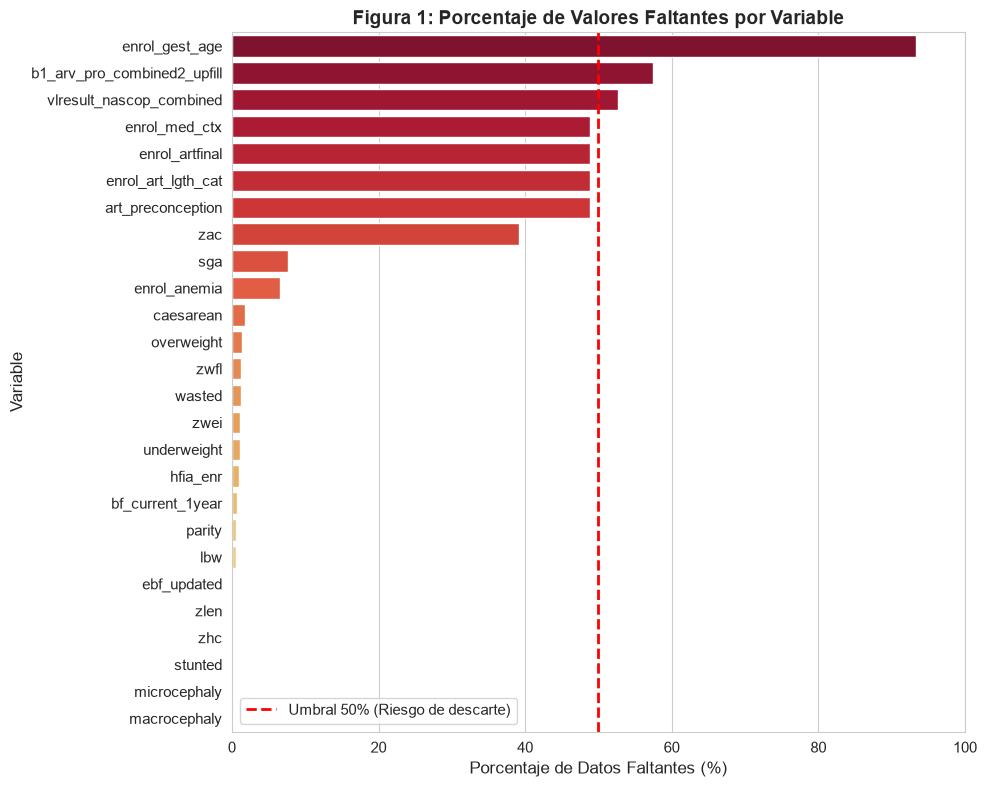

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PASO 3: Análisis de Missing Values con Lógica Clínica ---

# 1. Calcular porcentaje de missing por columna
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_df = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Variables con datos faltantes:")
print(missing_df)

# 2. SOLUCIÓN AL ERROR: Crear la carpeta 'figures' si no existe
os.makedirs('figures', exist_ok=True)

# 3. FIGURA 1: Gráfico de Barras de Missing Values
# Es limpio, profesional y perfecto para el PDF de la Entrega 1.
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_df.values, y=missing_df.index, palette='YlOrRd_r')
plt.title('Figura 1: Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Datos Faltantes (%)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.xlim(0, 100)
# Línea roja para identificar variables que podríamos descartar por tener >50% de missing
plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Umbral 50% (Riesgo de descarte)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig1_missing_values_bar.png', dpi=150, bbox_inches='tight')
plt.show()


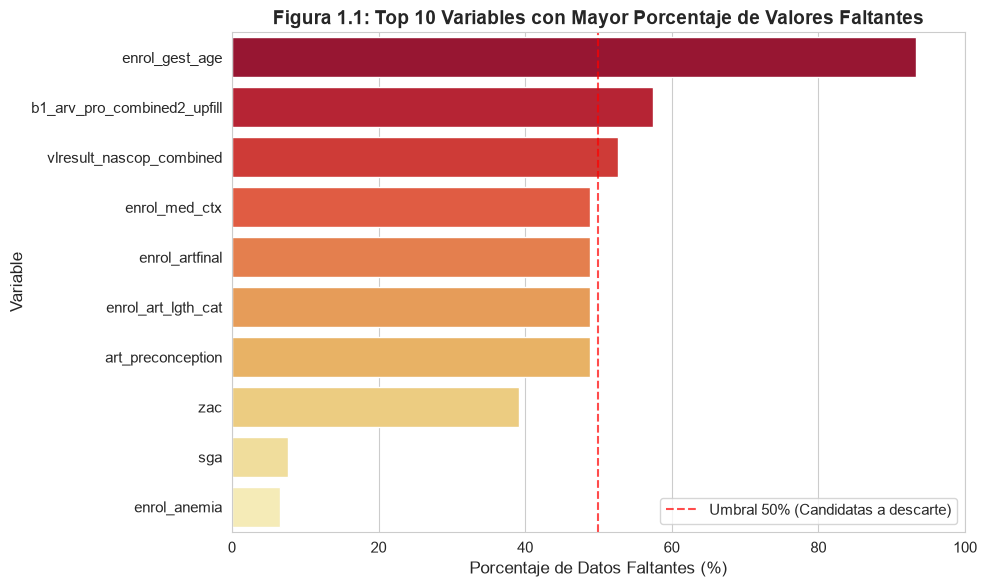

Nota para el reporte: Las variables con >50% de missing (ej. art_preconception) son estructurales,
ya que aplican solo a subpoblaciones específicas (madres HIV+). NO deben imputarse.


In [8]:
# ============================================================================
# 3.1 FIGURA 1.1: Gráfico de barras missing values Top 10
# ============================================================================
# Filtramos solo las 10 variables con mayor porcentaje de missing para mejorar la legibilidad en el reporte
top_10_missing = missing_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_missing.values, y=top_10_missing.index, palette='YlOrRd_r')
plt.title('Figura 1.1: Top 10 Variables con Mayor Porcentaje de Valores Faltantes', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Datos Faltantes (%)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.xlim(0, 100)

# Línea roja para identificar variables que podríamos descartar por tener >50% de missing
plt.axvline(50, ls='--', color='red', alpha=0.7, label='Umbral 50% (Candidatas a descarte)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig1.1_top10_missing.png', dpi=150, bbox_inches='tight')
plt.show()

print("Nota para el reporte: Las variables con >50% de missing (ej. art_preconception) son estructurales,")
print("ya que aplican solo a subpoblaciones específicas (madres HIV+). NO deben imputarse.")

### 3.1 Interpretación de valores faltantes (Figura 1)

El patrón de missing values **no es homogéneo** y se agrupa en tres bloques con implicaciones muy distintas:

1. **Missing estructural (>45%) — bloque VIH/ART y `enrol_gest_age`:**
   - `art_preconception`, `enrol_art_lgth_cat`, `enrol_artfinal` y `enrol_med_ctx` presentan ~48.8% de missing, que **coincide con la proporción de madres HIV-negativas** de la cohorte: estos campos solo se registran en madres HIV-positivas bajo tratamiento. Es un missing *por diseño del estudio*, no una falla de calidad del dato.
     - **Decisión:** **no imputar** (imputar ART a una madre HIV-negativa sería un error clínico). Dado que `enrol_hiv_status_cat` tiene 0% de missing y captura esa misma información, el bloque ART se excluye del set global de features o se codifica como "no aplica".
   - `vlresult_nascop_combined` (52.6%) y `b1_arv_pro_combined2_upfill` (57.5%) siguen la misma lógica: carga viral y profilaxis ARV del bebé solo aplican al subgrupo expuesto a VIH.
   - `enrol_gest_age` (93.3%) es inutilizable, pero **no se pierde información**: `gestage_final` (edad gestacional al nacimiento) tiene 0% de missing y la reemplazará. Esta variable es clave en el contexto Canguro para definir prematurez.

2. **Missing moderado (5–40%) — `zac` (39.1%), `sga` (7.7%), `enrol_anemia` (6.6%):**
   - `zac` (z-score de circunferencia de brazo) se analiza en la Figura 1b: su missing responde al protocolo de medición, no a abandono.
   - `sga` y `enrol_anemia` se manejarán con indicador de missing o imputación por moda.

3. **Missing despreciable (<2%):**
   - Variables sociodemográficas (predictoras) y outcomes antropométricos, incluido el target **`stunted` (0.1%)**. Esto garantiza la **confiabilidad del outcome** para el modelado supervisado: las trayectorias de crecimiento, eje central del proyecto, están prácticamente completas.

El umbral del 50% marcado en la Figura 1 deja **7 variables candidatas a exclusión directa**, en línea con las decisiones anteriores.



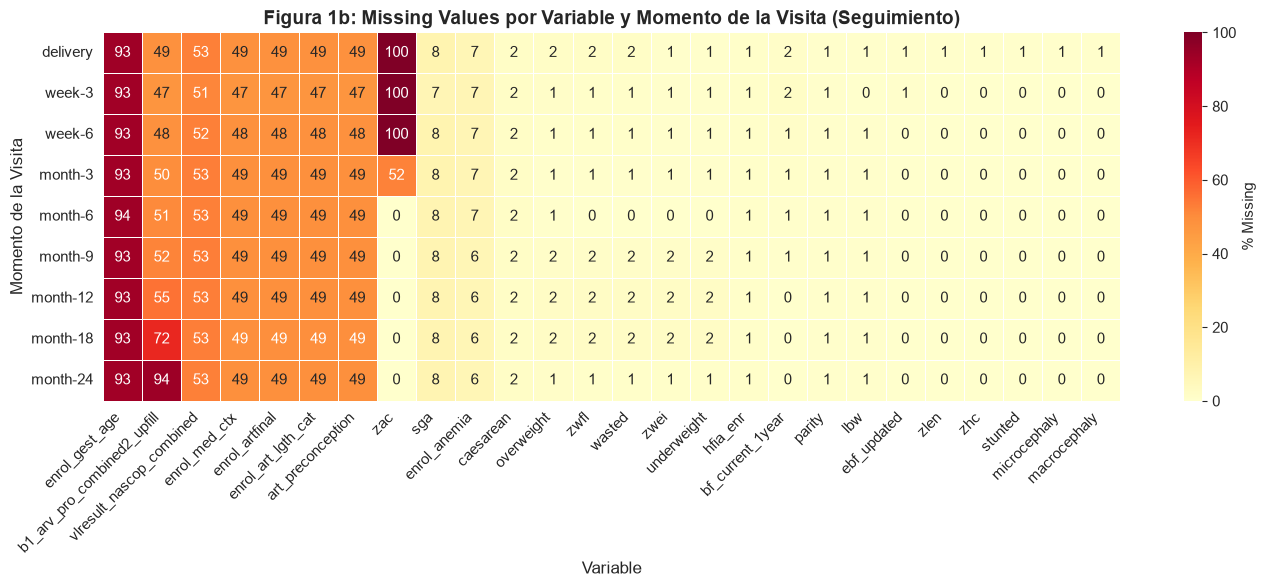


--- Verificación de lógica clínica ---
Missing en 'art_preconception' por estado HIV:
enrol_hiv_status_cat
Negative    1431
Positive       0
Name: art_preconception, dtype: int64

Conclusión: Los valores faltantes en variables ART (ej. art_preconception)
son estructurales para madres HIV-negativas. NO deben imputarse.


In [9]:
# 4. FIGURA 1b (ANÁLISIS LONGITUDINAL): Heatmap agrupado por Visita
# En lugar de graficar miles de filas, agrupamos por 'visit' para ver si 
# la pérdida de datos (attrition) empeora con los meses.
missing_by_visit = df.groupby('visit').agg(lambda x: (x.isnull().sum() / len(x) * 100)).round(1)
cols_missing = missing_df.index.tolist()
missing_by_visit_filtered = missing_by_visit[cols_missing]

# Ordenamos las visitas cronológicamente para que el heatmap tenga sentido clínico
visit_order = ['delivery', 'week-3', 'week-6', 'month-3', 'month-6', 'month-9', 'month-12', 'month-18', 'month-24']
visit_order = [v for v in visit_order if v in missing_by_visit_filtered.index]
missing_by_visit_filtered = missing_by_visit_filtered.loc[visit_order]

plt.figure(figsize=(14, 6))
sns.heatmap(missing_by_visit_filtered, cmap='YlOrRd', annot=True, fmt='.0f', 
            cbar_kws={'label': '% Missing'}, linewidths=.5)
plt.title('Figura 1b: Missing Values por Variable y Momento de la Visita (Seguimiento)', fontsize=14, fontweight='bold')
plt.ylabel('Momento de la Visita', fontsize=12)
plt.xlabel('Variable', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/fig1_missing_by_visit.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Verificación de lógica clínica
print("\n--- Verificación de lógica clínica ---")
print("Missing en 'art_preconception' por estado HIV:")
print(df.groupby('enrol_hiv_status_cat')['art_preconception'].apply(
    lambda x: x.isnull().sum()))
print("\nConclusión: Los valores faltantes en variables ART (ej. art_preconception)")
print("son estructurales para madres HIV-negativas. NO deben imputarse.")

### 3.2 Dimensión longitudinal del missing (Figura 1b)

- **El patrón estructural es constante entre visitas** (el bloque ART se mantiene en ~49% desde `delivery` hasta `month-24`): el missing responde al diseño y **no a deserción progresiva** del seguimiento. Esto simplifica el manejo longitudinal (no hay que modelar abandono creciente).
- **`zac` no se mide en el período neonatal:** 100% de missing en `delivery`, `week-3` y `week-6`, 52% en `month-3` y ~0% desde `month-6`.
  - **Implicación de modelado:** `zac` **no puede usarse como predictor temprano** (no existe en el momento en que queremos predecir). Se excluye del set de features basales y, de usarse, solo como variable disponible desde el mes 6, respetando la temporalidad para evitar *data leakage*.
- **`b1_arv_pro_combined2_upfill` aumenta su missing con el tiempo** (49% en delivery → 72% en `month-18` → 94% en `month-24`): la profilaxis es un campo que se registra solo en las primeras etapas y no debe usarse en visitas tardías.
- **Los outcomes antropométricos (`zlen`, `zwei`, `zhc`, `stunted`, `wasted`…) se mantienen en 0–2% en todas las visitas**, confirmando que el seguimiento antropométrico es sólido y que las trayectorias que se construirán en el siguiente paso son confiables.

### 3.3 Decisiones de preprocesamiento y modelado

| Decisión | Variable(s) | Razón |
|---|---|---|
| Excluir y reemplazar por `gestage_final` | `enrol_gest_age` | 93.3% missing; redundante con `gestage_final` (0% missing) |
| No imputar; excluir o codificar "no aplica" | Bloque ART/VIH (`art_preconception`, `enrol_art_lgth_cat`, `enrol_artfinal`, `enrol_med_ctx`, `vlresult…`, `b1_arv_pro…`) | Missing estructural por estado HIV; imputar sería un error clínico |
| Excluir del set de features tempranas | `zac` | No se mide antes del mes 3–6; usarlo generaría leakage |
| Indicador de missing / imputación por moda | `sga`, `enrol_anemia` | Missing moderado (6–8%) |
| Sin acción agresiva | Resto (<2%) | Missing despreciable; target `stunted` en 0.1% |

Estas decisiones garantizan que el modelo supervisado se entrene **únicamente con variables que existen en el momento en que se hará la predicción**, condición indispensable para un sistema de alerta temprana clínicamente útil y alineado con el objetivo del proyecto: identificar oportunidades de intervención antes de que las alteraciones del crecimiento se consoliden.

Conteos (visitas):
 stunted
no     2522
yes     410
Name: count, dtype: int64

Porcentajes:
 stunted
no     86.0
yes    14.0
Name: proportion, dtype: float64

Ratio no:yes ≈ 6.2 a 1
Missing del target: 2


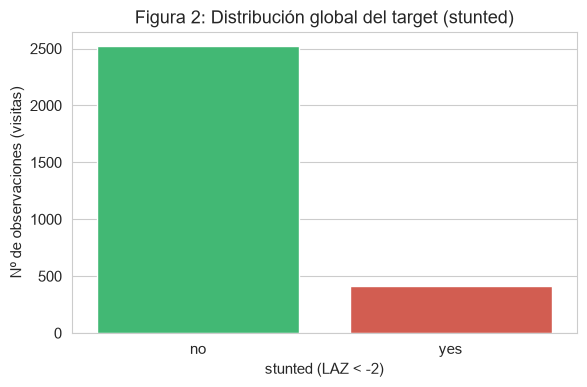

In [10]:
# --- PASO 4.1: Distribución global del target 'stunted' ---
target = df['stunted'].dropna()

conteos = target.value_counts()
pcts   = target.value_counts(normalize=True).mul(100).round(1)

print("Conteos (visitas):\n", conteos)
print("\nPorcentajes:\n", pcts)
print(f"\nRatio no:yes ≈ {(conteos['no']/conteos['yes']):.1f} a 1")
print(f"Missing del target: {df['stunted'].isna().sum()}")

plt.figure(figsize=(6, 4))
sns.countplot(x=target, order=['no', 'yes'], palette=['#2ecc71', '#e74c3c'])
plt.title('Figura 2: Distribución global del target (stunted)')
plt.xlabel('stunted (LAZ < -2)')
plt.ylabel('Nº de observaciones (visitas)')
plt.tight_layout()
plt.savefig('figures/fig2_target_global.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.1 Distribución global del target `stunted` (Figura 2)

El target presenta un **desbalance marcado entre clases**: de las 2,932 visitas válidas, 2,522 corresponden a `no` (86.0%) y 410 a `yes` (14.0%), es decir, un **ratio no:yes de ≈ 6.2:1**. Los valores faltantes del target son insignificantes (2 visitas, ~0.1%), por lo que el outcome puede considerarse **prácticamente completo**, lo cual da confiabilidad al análisis supervisado.

**Lectura en contexto clínico:**
- Una prevalencia del ~14% a nivel de visitas de desnutrición crónica (LAZ < −2) es consistente con el orden de magnitud reportado en cohortes de lactantes vulnerables (prematuros / bajo peso al nacer). Aunque `yes` es la clase minoritaria, es precisamente la clase de interés clínico: el evento que el modelo debe aprender a detectar a tiempo.

**Implicaciones de modelado (decisiones a implementar en semanas 4–5):**
1. **El accuracy no es una métrica útil aquí**: un clasificador trivial que siempre predijera `no` alcanzaría ~86% de acierto. El modelo se evaluará con **F1-score, precisión–recall (PR-AUC) y ROC-AUC**, priorizando la sensibilidad sobre la clase minoritaria.
2. **Manejo del desbalance**: se probará `class_weight='balanced'` y, de ser necesario, remuestreo (p. ej., SMOTE) aplicado **únicamente al partición de entrenamiento**, nunca a validación/prueba.
3. **Unidad de análisis y particionado**: cada fila es una *visita*, no un bebé (333 bebés aportan ~8.8 visitas en promedio). Como las visitas de un mismo bebé están correlacionadas, los splits de entrenamiento/validación/prueba deberán hacerse **por bebé (`newid`)** (*grouped split*) para evitar fuga de datos y sobreestimación del desempeño.
4. **Estratificación**: se conservará la proporción 86/14 en cada fold mediante estratificación, para garantizar evaluaciones estables.

**Transición:** Esta vista global oculta el *cuándo*: el 14% no se distribuye uniformemente en el tiempo. En el Bloque 4.2 se examina la prevalencia de stunting **por visita**, para identificar en qué momentos del primer año se concentra y acumula el riesgo — información clave para definir el horizonte de predicción del modelo y la ventana de oportunidad de intervención.

visit
delivery     8.5
week-3       7.6
week-6       7.6
month-3     10.0
month-6     11.0
month-9     10.4
month-12    15.0
month-18    26.4
month-24    29.4
Name: stunted, dtype: float64


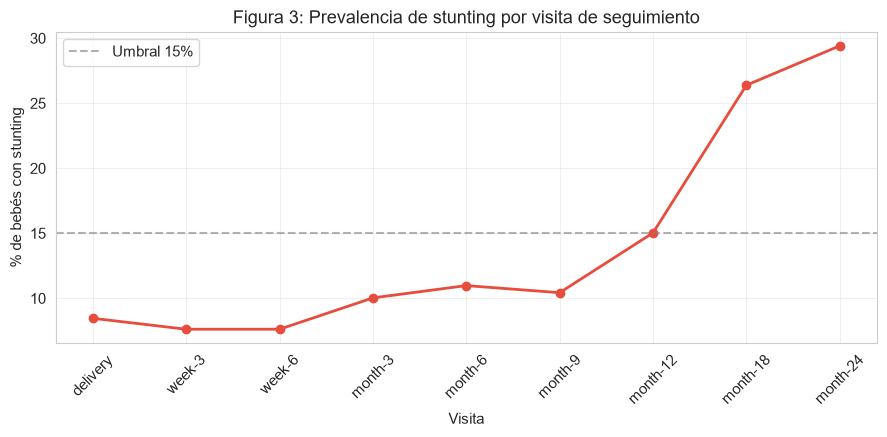

In [11]:
# --- PASO 4.2: Prevalencia de stunted por visita ---
orden_visitas = ['delivery', 'week-3', 'week-6', 'month-3', 'month-6',
                 'month-9', 'month-12', 'month-18', 'month-24']

prev = (df.groupby('visit')['stunted']
          .apply(lambda s: (s == 'yes').sum() / s.notna().sum() * 100)
          .reindex(orden_visitas))
print(prev.round(1))

plt.figure(figsize=(9, 4.5))
plt.plot(prev.index, prev.values, marker='o', color='#e74c3c', linewidth=2)
plt.axhline(15, ls='--', color='gray', alpha=0.6, label='Umbral 15%')
plt.title('Figura 3: Prevalencia de stunting por visita de seguimiento')
plt.ylabel('% de bebés con stunting')
plt.xlabel('Visita')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig3_prevalencia_por_visita.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Prevalencia de stunting por visita (Figura 3)

La prevalencia de stunting **no es constante en el tiempo**: la curva muestra dos fases claramente diferenciadas.

- **Fase contenida (nacimiento – 12 meses):** la prevalencia oscila entre 7.6% y 11%. Alrededor de un 8.5% de los bebés ya presenta stunting **al nacer**, lo que corresponde a un componente de origen intrauterino (asociado a restricción del crecimiento intrauterino, prematurez y PEG).
- **Fase de aceleración (12 – 24 meses):** la prevalencia salta de 15.0% (month-12) a 26.4% (month-18) y 29.4% (month-24): casi **3.5 veces** el valor al nacimiento.

**Interpretación en contexto del proyecto:**
- El stunting en esta cohorte es predominantemente un fenómeno **adquirido y progresivo**: la mayoría de los bebés que terminan con desnutrición crónica a los 24 meses no lo estaban al nacer. El deterioro se concentra después del primer año, periodo que coincide con el destete, la alimentación complementaria y mayor exposición a infecciones e inseguridad alimentaria.
- El periodo **nacimiento – 12 meses** se configura así como la **ventana de oportunidad para intervención temprana**: existe tiempo para detectar señales tempranas y actuar antes de que el deterioro se consolide. Esta es precisamente la lógica de los programas de seguimiento tipo Madre Canguro.
- El salto posterior al mes 12 sugiere que el seguimiento clínico **no debe relajarse al año de vida**, sino intensificarse entre los 12 y 24 meses.

**Implicaciones de modelado:**
1. El target es **dinámico en el tiempo**: un mismo bebé cambia de clase según la visita en que se le evalúe. La definición del outcome (stunting a 12m vs. 24m) debe quedar explícita en el alcance del modelo.
2. El 14% global del Bloque 4.1 mezcla visitas con prevalencias entre 7.6% y 29.4%; por ello, los análisis estratificados por visita o por bebé son más informativos que el agregado.
3. El patrón justifica el valor de la **predicción temprana**: con información disponible al nacimiento o en los primeros meses, el modelo debería anticipar qué bebés entrarán en la fase de aceleración del deterioro.

In [12]:
# --- PASO 4.3: Transición del estado nutricional por bebé ---
estado = df.pivot_table(index='newid', columns='visit',
                        values='stunted', aggfunc='first')

print("Transición delivery -> month-12:")
print(pd.crosstab(estado['delivery'], estado['month-12'], margins=True))

print("\nTransición delivery -> month-24:")
print(pd.crosstab(estado['delivery'], estado['month-24'], margins=True))

Transición delivery -> month-12:
month-12   no  yes  All
delivery               
no        264   32  296
yes        13   15   28
All       277   47  324

Transición delivery -> month-24:
month-24   no  yes  All
delivery               
no        216   78  294
yes        10   17   27
All       226   95  321


### 4.3 Transición del estado nutricional: ¿el stunting se nace o se adquiere?

Las matrices de transición entre el nacimiento y los 12/24 meses (≈324 y ≈321 bebés con dato pareado; pérdida de seguimiento mínima, lo que da confiabilidad al análisis) muestran que el stunting en esta cohorte es **predominantemente adquirido**:

- **A los 12 meses:** de los 47 bebés con stunting, **32 (68%) no lo presentaban al nacer** (casos incidentes) y solo 15 (32%) lo traían de nacimiento. Entre los 296 bebés sanos al nacer, **32 (10.8%)** desarrollaron stunting antes del año.
- **A los 24 meses:** de los 95 bebés con stunting, **78 (82%)** eran sanos al nacer. La incidencia acumulada entre los sanos al nacer se más que duplica: **26.5%** (78/294) frente al 10.8% del primer año.
- **El stunting al nacer no es un destino:** ≈**46%** de los recién nacidos con stunting ya lo había superado a los 12 meses (crecimiento compensatorio o *catch-up*); hacia los 24 meses, el 63% de los que nacieron con stunting persiste o recae, mientras un 37% logra recuperarse.

**Interpretación en contexto del proyecto:**
- El deterioro del crecimiento ocurre **después del nacimiento**, durante el periodo postnatal (coherente con el salto de prevalencia visto en el Bloque 4.2 tras el mes 12). Esto confirma que existe una **ventana de oportunidad real** para la detección y la intervención temprana (nutrición, lactancia materna exclusiva, seguimiento tipo Programa Madre Canguro).
- Como la mayoría de los casos futuros **nacen "sanos"**, un sistema de alerta basado solo en información del nacimiento debe capturar la vulnerabilidad de base (socioeconómica, clínica, alimentaria); por ello el **seguimiento longitudinal** y la incorporación de mediciones postnales tempranas son clave para anticipar el fallo de crecimiento.

**Implicaciones de modelado:**
1. El target debe definirse con **horizonte explícito** (stunting a 12 m vs. 24 m): la prevalencia y la composición de los casos (adquiridos vs. persistentes) cambian sustancialmente.
2. Dado que ≥68% de los casos son adquiridos, las **features postnales tempranas** (p. ej. Z-scores en week-3 / month-3) probablemente aporten más poder predictivo que las variables basales solas — respetando siempre la temporalidad para evitar *data leakage*.
3. La clase "recuperada" (*catch-up*) indica que el modelo también puede identificar bebés con riesgo al nacer que **revierten** su riesgo: útil para priorizar recursos sin sobre-tratar.

Madres/bebés únicos: 333

--- enrol_hiv_status_cat (faltantes=0) ---
                        n     %
enrol_hiv_status_cat           
Positive              171  51.4
Negative              162  48.6

--- momage_cat (faltantes=0) ---
               n     %
momage_cat            
26 to 35     158  47.4
25 and less  124  37.2
35 and more   51  15.3

--- educ_cat_n (faltantes=0) ---
                       n     %
educ_cat_n                    
Primary or below     214  64.3
Secondary and above  119  35.7

--- marital_cat (faltantes=0) ---
               n     %
marital_cat           
Married      282  84.7
Other         51  15.3

--- wealth_quintile (faltantes=0) ---
                   n     %
wealth_quintile           
lowest quintile   68  20.4
quintile4         68  20.4
quintile2         66  19.8
quintile3         66  19.8
highest quintile  65  19.5


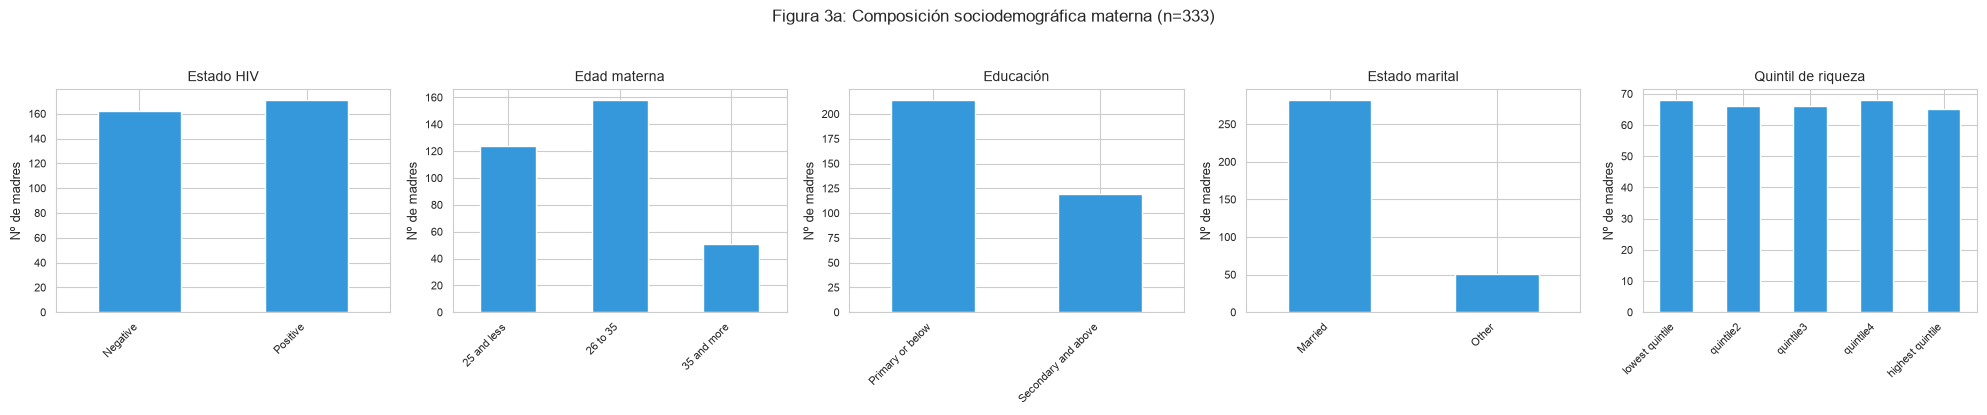

In [13]:
# --- PASO 5: Variables maternas al enrolamiento (features basales) ---
# --- PASO 5.1: Composición sociodemográfica de la cohorte materna ---
# Las variables maternas no cambian entre visitas: usamos UNA fila por madre/bebé.
moms = df.drop_duplicates('newid').copy()
print(f"Madres/bebés únicos: {len(moms)}")

socio = ['enrol_hiv_status_cat', 'momage_cat', 'educ_cat_n', 'marital_cat', 'wealth_quintile']
titulos = {'enrol_hiv_status_cat': 'Estado HIV', 'momage_cat': 'Edad materna',
           'educ_cat_n': 'Educación', 'marital_cat': 'Estado marital',
           'wealth_quintile': 'Quintil de riqueza'}
ordenes = {'enrol_hiv_status_cat': ['Negative', 'Positive'],
           'momage_cat': ['25 and less', '26 to 35', '35 and more'],
           'educ_cat_n': ['Primary or below', 'Secondary and above'],
           'marital_cat': ['Married', 'Other'],
           'wealth_quintile': ['lowest quintile', 'quintile2', 'quintile3',
                               'quintile4', 'highest quintile']}

# Resumen numérico (esto es lo que necesito para el markdown)
for col in socio:
    vc = moms[col].value_counts(dropna=False)
    pct = (vc / len(moms) * 100).round(1)
    print(f"\n--- {col} (faltantes={moms[col].isna().sum()}) ---")
    print(pd.DataFrame({'n': vc, '%': pct}))

# Figura 3a
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, socio):
    counts = moms[col].value_counts().reindex(ordenes[col])
    counts.plot(kind='bar', ax=ax, color='#3498db')
    ax.set_title(titulos[col], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Nº de madres', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Figura 3a: Composición sociodemográfica materna (n={len(moms)})',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('figures/fig3a_maternal_socio.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Composición sociodemográfica de la cohorte materna (Figura 3a)

Sobre las 333 madres/bebés únicos, las variables sociodemográficas al enrolamiento no presentan valores faltantes y muestran el siguiente perfil:

- **Estado HIV:** casi balanceado por diseño del estudio original — 51.4% positivas (171) vs 48.6% negativas (162). Esto **confirma la hipótesis del Paso 3**: el ~49% de missing en el bloque ART/CTX/carga viral corresponde a madres HIV-negativas para quienes esos campos no aplican (missing estructural, no imputable).
- **Edad materna:** cohorte joven — 37.2% tiene ≤25 años (incluye adolescentes) y solo 15.3% es mayor de 35.
- **Educación:** predomina baja escolaridad — 64.3% primaria o menos vs 35.7% secundaria o más.
- **Estado marital:** 84.7% casadas.
- **Quintil de riqueza:** distribución prácticamente uniforme (~20% por quintil), como corresponde a una variable construida por quintiles.

**Lectura en contexto del proyecto:**
- El perfil (madres jóvenes, baja escolaridad, mayoría casadas) describe una población socioeconómicamente vulnerable, coherente con los contextos de programas tipo Madre Canguro: los determinantes sociales (educación, riqueza relativa, inseguridad alimentaria) son candidatos naturales a predictores del fallo de crecimiento.
- El balance HIV ~50/50 implica que el estado HIV no dominará el modelo por pura prevalencia; pero es la variable de exposición central del estudio original, por lo que conviene analizar las trayectorias también **estratificadas por HIV** (bebés expuestos-no-infectados vs no expuestos).
- La uniformidad de quintiles evita categorías raritas al codificar (buen comportamiento en modelos); su interpretación es de posición socioeconómica *relativa dentro de la cohorte*, no riqueza absoluta.

**Implicaciones de modelado:**
1. Las cinco variables están completas (0 faltantes) y son conocidas al enrolamiento → entran directamente al set de features basales, sin imputación y sin riesgo de fuga temporal.
2. Categóricas de pocos niveles → codificación simple (one-hot u ordinal); los modelos basados en árboles las manejan sin preprocesamiento mayor.

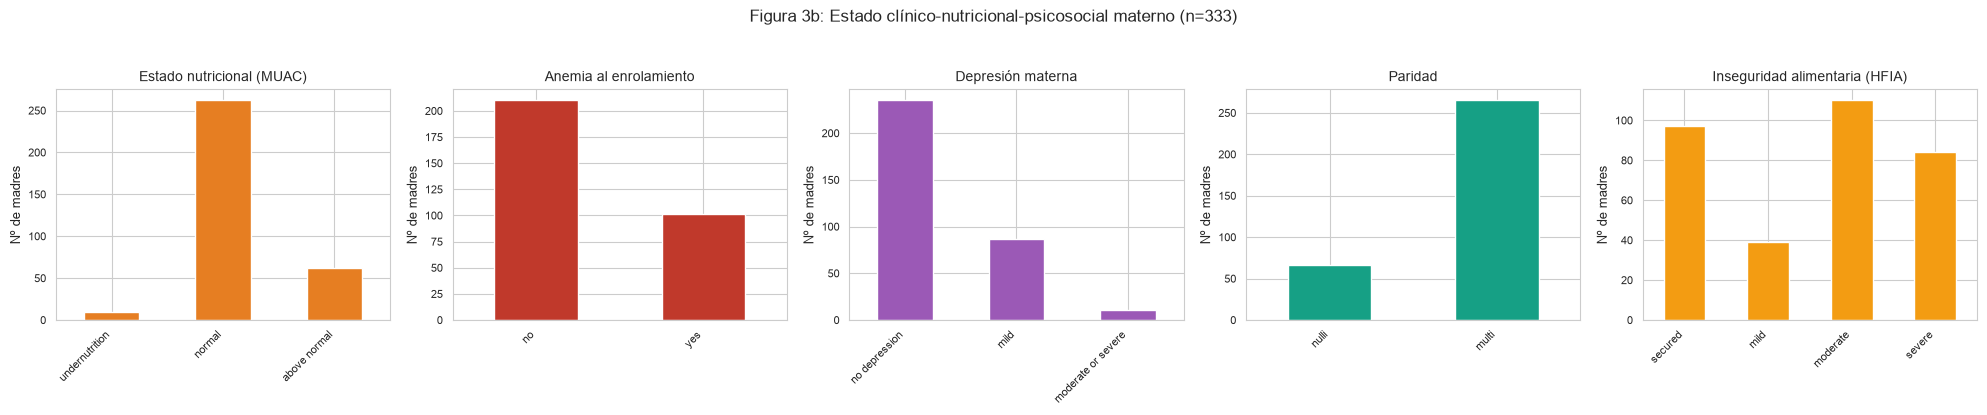

In [16]:
# --- PASO 5.2: Estado clínico, nutricional y psicosocial materno al enrolamiento ---
clin = ['mom_muac_cat', 'enrol_anemia', 'depression', 'parity', 'hfia_enr']   # <- línea que faltaba

ordenes = {'mom_muac_cat': ['undernutrition', 'normal', 'above normal'],
           'enrol_anemia': ['no', 'yes'],
           'depression': ['no depression', 'mild', 'moderate or severe'],
           'parity': ['nulli', 'multi'],   # <- corregido
           'hfia_enr': ['secured', 'mild', 'moderate', 'severe']}
titulos = {'mom_muac_cat': 'Estado nutricional (MUAC)', 'enrol_anemia': 'Anemia al enrolamiento',
           'depression': 'Depresión materna', 'parity': 'Paridad', 'hfia_enr': 'Inseguridad alimentaria (HFIA)'}
colores = {'mom_muac_cat': '#e67e22', 'enrol_anemia': '#c0392b', 'depression': '#9b59b6',
           'parity': '#16a085', 'hfia_enr': '#f39c12'}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, clin):
    moms[col].value_counts().reindex(ordenes[col]).plot(kind='bar', ax=ax, color=colores[col])
    ax.set_title(titulos[col], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Nº de madres', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle(f'Figura 3b: Estado clínico-nutricional-psicosocial materno (n={len(moms)})', fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('figures/fig3b_maternal_clinico.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Estado clínico, nutricional y psicosocial materno (Figura 3b)

A diferencia del bloque sociodemográfico, estas variables describen la *salud y el bienestar* de la madre al enrolamiento, y muestran una variabilidad clínicamente relevante:

- **Inseguridad alimentaria (HFIA):** solo 29.1% de los hogares tiene alimentación asegurada; **~70% presenta algún grado de inseguridad** (moderada 33.0%, severa 25.2%, leve 11.7%). Es el determinante con mayor carga en la cohorte.
- **Anemia al enrolamiento:** 30.3% de las madres presenta anemia (6.6% de faltantes, a manejar en el pipeline).
- **Depresión materna:** 29.4% con algún síntoma (leve 26.1%, moderada/severa 3.3%).
- **Estado nutricional (MUAC):** 78.7% normal; la desnutrición materna es rara (2.7%), aunque clínicamente relevante.
- **Paridad:** 79.6% multíparas (0.6% de faltantes, despreciable).

**Lectura en contexto del proyecto:**
- La co-ocurrencia de inseguridad alimentaria (~70%), anemia (~30%) y síntomas depresivos (~29%) configura un perfil de vulnerabilidad **modificable/monitoreable** que la literatura asocia con prácticas de alimentación y adherencia al seguimiento subóptimas, y por ende con el fallo de crecimiento infantil.
- Todas son conocidas al enrolamiento → entran al set de features basales **sin riesgo de fuga temporal**.

**Implicaciones de modelado:**
1. **Categorías raras** (MUAC desnutrición n=9; depresión moderada/severa n=11): los modelos basados en árboles las manejan, pero con bajo soporte; en la etapa de ingeniería de features (semanas 4–5) se evaluarán *flags* binarios (p. ej., "alguna depresión", "inseguridad moderada/severa").
2. **`enrol_anemia` (6.6% missing):** se manejará con indicador de faltante o imputación **dentro del pipeline de entrenamiento**, nunca antes de particionar.
3. La asociación de estas variables con `stunted` se verificará en el Paso 8; por ahora el EDA confirma que hay variabilidad suficiente para aportar señal predictiva.

Bebés únicos: 333

Edad gestacional al nacer (semanas):
count    333.00
mean      39.09
std        2.00
min       31.61
25%       38.00
50%       39.00
75%       40.00
max       48.48
Name: gestage_final, dtype: float64


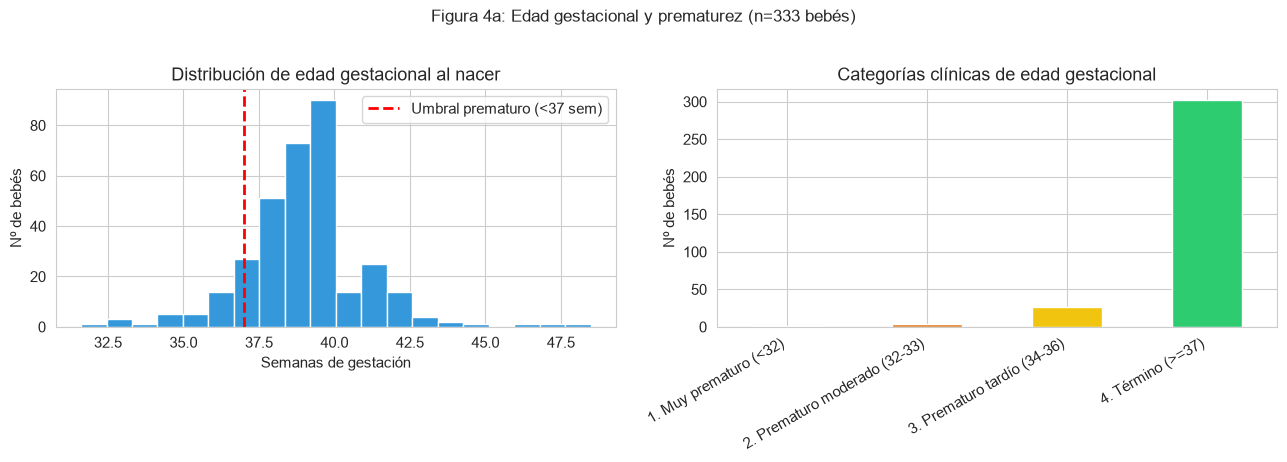


Categorías de edad gestacional:
                                 n     %
cat_gest                                
1. Muy prematuro (<32)           1   0.3
2. Prematuro moderado (32-33)    4   1.2
3. Prematuro tardío (34-36)     26   7.8
4. Término (>=37)              302  90.7

Variable binaria 'preterm':
           n     %
preterm           
no       302  90.7
yes       31   9.3

% según variable 'preterm'==yes : 9.3%
% según gestage_final < 37     : 9.3%


In [17]:
# --- PASO 6 Variables del nacimiento — el perfil neonatal de vulnerabilidad de la cohorte
# --- PASO 6.1: Edad gestacional al nacer y prematurez ---
# Una fila por bebé (las variables del nacimiento son fijas)
bebes = df.drop_duplicates('newid').copy()
print(f"Bebés únicos: {len(bebes)}")

# Resumen numérico de edad gestacional (semanas)
print("\nEdad gestacional al nacer (semanas):")
print(bebes['gestage_final'].describe().round(2))

# Categorías clínicas de edad gestacional
def cat_gest(g):
    if pd.isna(g): return '5. NA'
    if g < 32:  return '1. Muy prematuro (<32)'
    if g < 34:  return '2. Prematuro moderado (32-33)'
    if g < 37:  return '3. Prematuro tardío (34-36)'
    return '4. Término (>=37)'

bebes['cat_gest'] = bebes['gestage_final'].apply(cat_gest)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# a) Histograma con umbral de prematurez
axes[0].hist(bebes['gestage_final'].dropna(), bins=20, color='#3498db', edgecolor='white')
axes[0].axvline(37, color='red', ls='--', lw=2, label='Umbral prematuro (<37 sem)')
axes[0].set_title('Distribución de edad gestacional al nacer')
axes[0].set_xlabel('Semanas de gestación')
axes[0].set_ylabel('Nº de bebés')
axes[0].legend()

# b) Categorías clínicas
vc = bebes['cat_gest'].value_counts().sort_index()
colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#95a5a6']
vc.plot(kind='bar', ax=axes[1], color=colores[:len(vc)])
axes[1].set_title('Categorías clínicas de edad gestacional')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nº de bebés')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle(f'Figura 4a: Edad gestacional y prematurez (n={len(bebes)} bebés)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig4a_gestacional.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de resumen para el análisis
print("\nCategorías de edad gestacional:")
print(pd.DataFrame({'n': vc, '%': (vc / len(bebes) * 100).round(1)}))

# Prevalencia de prematurez (variable binaria 'preterm')
pt = bebes['preterm'].value_counts(dropna=False)
print("\nVariable binaria 'preterm':")
print(pd.DataFrame({'n': pt, '%': (pt / len(bebes) * 100).round(1)}))

# Control de calidad: consistencia entre 'preterm' y gestage < 37
print(f"\n% según variable 'preterm'==yes : {(bebes['preterm']=='yes').mean()*100:.1f}%")
print(f"% según gestage_final < 37     : {(bebes['gestage_final']<37).mean()*100:.1f}%")

### 6.1 Edad gestacional al nacer y prematurez (Figura 4a)

La distribución de edad gestacional se concentra en el término: media de 39.1 semanas (DE ±2.0), mediana de 39 semanas y RIC de 38–40 semanas. Aproximadamente el 90% de los bebés nació con ≥37 semanas; la prematurez (<37 semanas) ronda el 9–10% (≈30 de 333 bebés), compuesta casi en su totalidad por **prematuros tardíos (34–36 semanas, ≈25 bebés)**, con prematuridad moderada (32–33 semanas) rara y prematuridad muy extrema (<32 semanas) prácticamente ausente.

**Lectura en contexto del proyecto:**
- A diferencia de la población de la Fundación Canguro (100% prematuros/BPN por definición del programa), esta cohorte de Kenia es una cohorte de seguimiento de bebés expuestos y no expuestos a VIH donde la prematurez ocurre a tasas cercanas a las poblacionales. El subgrupo de "recién nacido vulnerable" es, por tanto, pequeño. Esto refuerza dos decisiones tomadas antes: (i) usar **stunting como target principal** (tiene mucha más prevalencia), y (ii) tratar **preterm/BPN/PEG como features predictivas del nacimiento**, no como objetivo de análisis.
- La casi ausencia de prematuros <32 semanas implica que cualquier análisis de subgrupo en ese estrato estará subpotenciado: se interpretará con cautela.

**Calidad de dato:**
- La cola derecha incluye registros **biológicamente implausibles** (>44 semanas; máx. 48.5). Se marcarán para revisión/limitación (*winsorización*) en la etapa de preprocesamiento (semanas 4–5); en el EDA no se corrigen, solo se documentan.

**Implicaciones de modelado:**
- La variable binaria `preterm` es desbalanceada (~1:10) pero usable como feature; se evaluará también `gestage_final` como variable continua para capturar el gradiente dosis-respuesta en la cola izquierda (a menor edad gestacional, mayor riesgo de fallo de crecimiento).

Bebés únicos: 333

--- lbw (faltantes=2) ---
       n     %
lbw           
no   311  93.4
yes   20   6.0
NaN    2   0.6

--- sga (faltantes=27) ---
       n     %
sga           
no   277  83.2
yes   29   8.7
NaN   27   8.1

Cruce lbw x preterm:
preterm   no  yes  All
lbw                   
no       285   26  311
yes       15    5   20
All      300   31  331

Cruce sga x preterm:
preterm   no  yes  All
sga                   
no       259   18  277
yes       22    7   29
All      281   25  306

Desglose del BPN por etiología:
Prematuro y PEG    3
Solo prematuro     2
Solo PEG (RCIU)    7
Ninguno            7
PEG faltante       1
dtype: int64

Perfil de vulnerabilidad neonatal (cohorte completa):
perfil
Solo prematuro      18
Solo PEG (RCIU)     22
Prematuro + PEG      7
Ninguno            265
PEG faltante        21
Name: count, dtype: int64


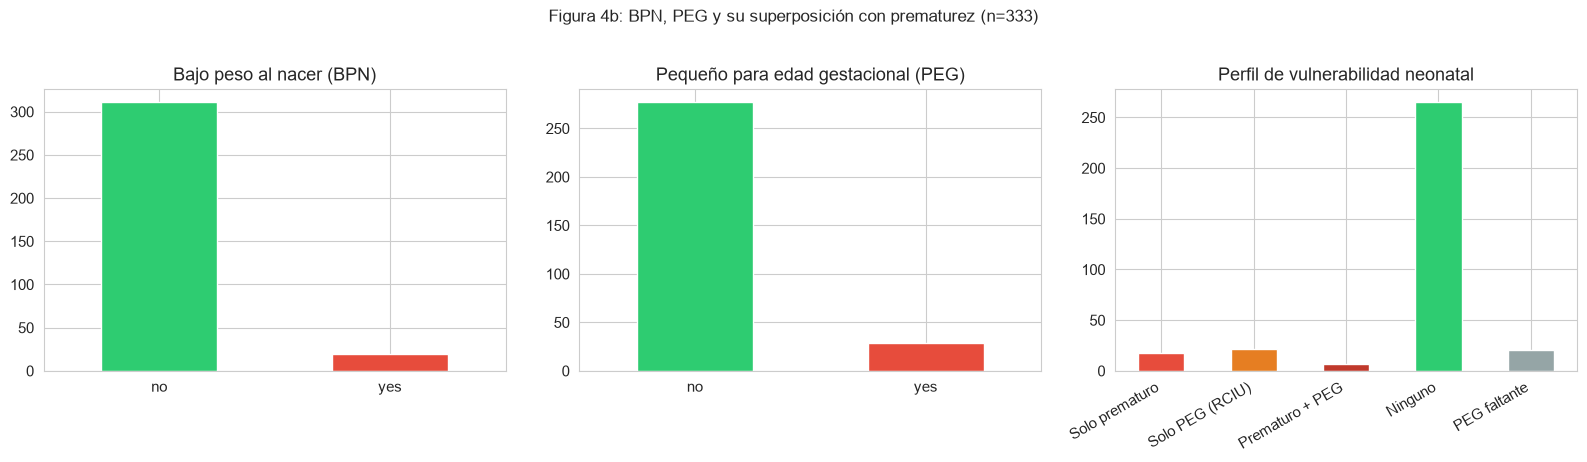

In [18]:
# --- PASO 6.2: Bajo peso al nacer (BPN), PEG y su superposición con prematurez ---
# Una fila por bebé; estas variables son features del nacimiento (sin fuga temporal)
bebes = df.drop_duplicates('newid').copy()
print(f"Bebés únicos: {len(bebes)}")

# 1) Prevalencia de BPN y PEG
for col in ['lbw', 'sga']:
    vc = bebes[col].value_counts(dropna=False)
    pct = (vc / len(bebes) * 100).round(1)
    print(f"\n--- {col} (faltantes={bebes[col].isna().sum()}) ---")
    print(pd.DataFrame({'n': vc, '%': pct}))

# 2) Superposición entre condiciones
print("\nCruce lbw x preterm:")
print(pd.crosstab(bebes['lbw'], bebes['preterm'], margins=True))

print("\nCruce sga x preterm:")
print(pd.crosstab(bebes['sga'], bebes['preterm'], margins=True))

# 3) Desglose etiológico del BPN: ¿premadurez o restricción de crecimiento (RCIU)?
lbw_yes = bebes[bebes['lbw'] == 'yes']
print("\nDesglose del BPN por etiología:")
print(pd.Series({
    'Prematuro y PEG':   ((lbw_yes['preterm']=='yes') & (lbw_yes['sga']=='yes')).sum(),
    'Solo prematuro':    ((lbw_yes['preterm']=='yes') & (lbw_yes['sga']=='no')).sum(),
    'Solo PEG (RCIU)':   ((lbw_yes['preterm']=='no')  & (lbw_yes['sga']=='yes')).sum(),
    'Ninguno':           ((lbw_yes['preterm']=='no')  & (lbw_yes['sga']=='no')).sum(),
    'PEG faltante':      lbw_yes['sga'].isna().sum(),
}))

# 4) Perfil de vulnerabilidad neonatal de TODA la cohorte
bebes['perfil'] = 'Ninguno'
bebes.loc[(bebes['preterm']=='yes') & (bebes['sga']=='yes'), 'perfil'] = 'Prematuro + PEG'
bebes.loc[(bebes['preterm']=='yes') & (bebes['sga']=='no'), 'perfil'] = 'Solo prematuro'
bebes.loc[(bebes['preterm']=='no')  & (bebes['sga']=='yes'), 'perfil'] = 'Solo PEG (RCIU)'
bebes.loc[(bebes['preterm']=='no')  & (bebes['sga'].isna()), 'perfil'] = 'PEG faltante'
orden = ['Solo prematuro', 'Solo PEG (RCIU)', 'Prematuro + PEG', 'Ninguno', 'PEG faltante']

print("\nPerfil de vulnerabilidad neonatal (cohorte completa):")
print(bebes['perfil'].value_counts().reindex(orden))

# FIGURA 4b
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bebes['lbw'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Bajo peso al nacer (BPN)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

bebes['sga'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Pequeño para edad gestacional (PEG)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

bebes['perfil'].value_counts().reindex(orden).plot(
    kind='bar', ax=axes[2], color=['#e74c3c', '#e67e22', '#c0392b', '#2ecc71', '#95a5a6'])
axes[2].set_title('Perfil de vulnerabilidad neonatal')
axes[2].set_xlabel('')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.suptitle(f'Figura 4b: BPN, PEG y su superposición con prematurez (n={len(bebes)})',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig4b_lbw_sga.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Bajo peso al nacer (BPN), PEG y su superposición con prematurez (Figura 4b)

- **Prevalencias:** BPN 6.0% (20/331); PEG 8.7% (29/306). `sga` concentra 8.1% de faltantes (27 bebés), que se manejarán con indicador de missing en el pipeline; `lbw` es prácticamente completo (2 faltantes).
- **El BPN ocurre mayoritariamente en bebés a término:** de los 20 BPN, 15 (75%) **no** son prematuros. El desglose etiológico muestra que las vías dominantes son **PEG solo (RCIU)** (7 casos, 35%) y "ni prematuro ni PEG" (7, 35%); la prematuridad sola explica apenas 2 casos (10%).
- **El PEG también es predominantemente a término:** de los 29 PEG, 22 (76%) nacieron a término.
- **Perfil de vulnerabilidad neonatal (cohorte completa):** 79.6% sin condición (265); **PEG solo (RCIU) 6.6% (22)**; **prematuro solo 5.4% (18)**; prematuro+PEG 2.1% (7); PEG faltante 6.3% (21). El **14.1% (47/333)** presenta alguna condición de vulnerabilidad neonatal.

**Lectura en contexto del proyecto:**
- En esta cohorte, la **restricción de crecimiento intrauterino (RCIU/PEG) es más frecuente que la prematuridad** y apenas se superpone con ella (7 bebés). Prematuridad y PEG capturan bebés vulnerables *distintos*: está justificado incluir ambas como features basales separadas, no como un único indicador de "recién nacido vulnerable".
- Comparado con la población de la Fundación Canguro (100% prematuros/BPN por definición del programa), aquí el "núcleo canguro" es minoritario (~14%). Esto reafirma el rol del dataset como *proxy*: su valor está en las trayectorias longitudinales y los determinantes del stunting, mientras el subgrupo vulnerable neonatal funciona como estrato de análisis.
- Que el 75% del BPN sea a término sugiere que factores maternos/placentarios (nutrición, anemia, inseguridad alimentaria) pesan más que la edad gestacional en esta población — coherente con los determinantes sociales observados en el Paso 5.

**Implicaciones de modelado:**
1. `preterm`, `sga` y `lbw` son features binarias conocidas al nacimiento; solo `sga` requiere manejo de missing (8.1%).
2. Sus bajas prevalencias (6–9%) las harían targets desbalanceados, pero como *features* de stunting aportan señal sin dominar el modelo.
3. La superposición prematuro∩PEG es mínima (7/333) → no hay colinealidad entre ambas; pueden conservarse juntas.

Bebés según stunting a los 24 meses:
stunted_24
no     228
yes     95
Name: count, dtype: int64


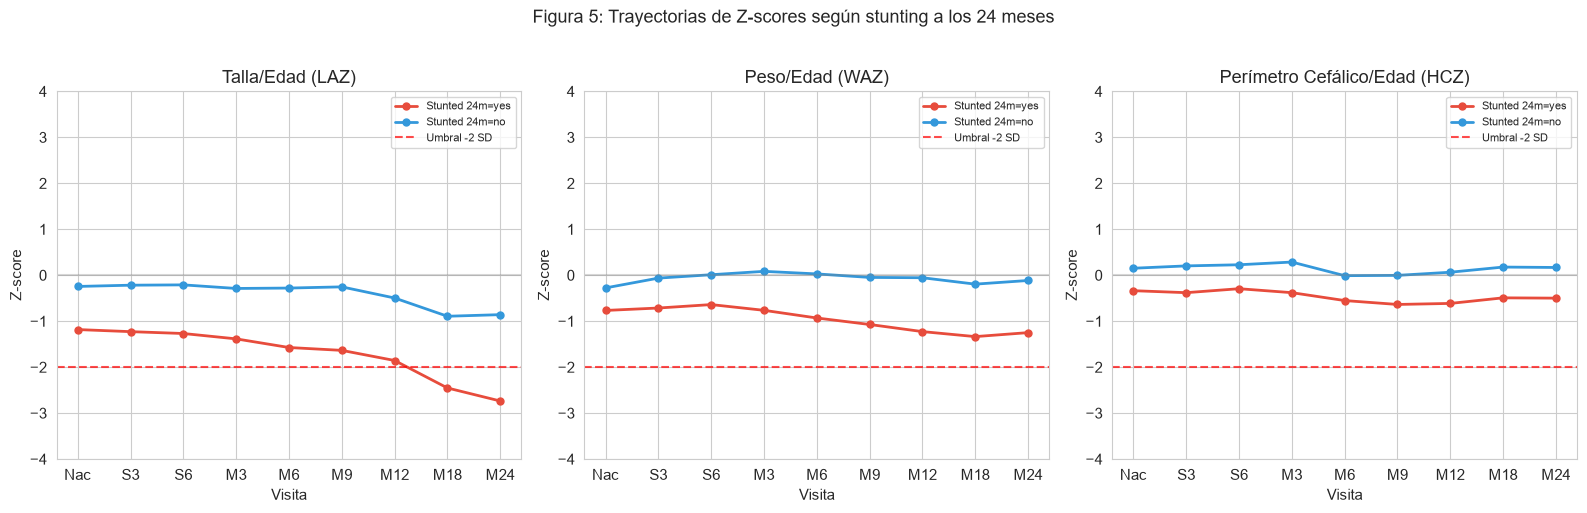

In [19]:
# --- PASO 7: Curvas de Crecimiento (Z-scores por visita) ---
# --- PASO 7.1: Trayectorias de Z-scores según stunting a los 24 meses ---
# Grupo a nivel de bebé: estado de stunting en la visita de month-24.
# (Si prefieres "alguna vez stunted", cambia la visita de referencia.)

st24 = (df.loc[df['visit'] == 'month-24', ['newid', 'stunted']]
          .rename(columns={'stunted': 'stunted_24'}))
df = df.merge(st24, on='newid', how='left')

print("Bebés según stunting a los 24 meses:")
print(st24['stunted_24'].value_counts())

# Asegura el orden cronológico de visitas
orden_visitas = ['delivery', 'week-3', 'week-6', 'month-3', 'month-6',
                 'month-9', 'month-12', 'month-18', 'month-24']
if 'visit_order' not in df.columns:
    df['visit_order'] = df['visit'].map({v: i for i, v in enumerate(orden_visitas)})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

z_scores = ['zlen', 'zwei', 'zhc']
titulos  = ['Talla/Edad (LAZ)', 'Peso/Edad (WAZ)', 'Perímetro Cefálico/Edad (HCZ)']
colores  = {'yes': '#e74c3c', 'no': '#3498db'}

for ax, z_col, titulo in zip(axes, z_scores, titulos):
    for grupo, color in colores.items():
        tr = (df[df['stunted_24'] == grupo]
              .groupby('visit_order')[z_col].mean()
              .reindex(range(len(orden_visitas))))
        ax.plot(tr.index, tr.values, marker='o', color=color,
                label=f'Stunted 24m={grupo}', linewidth=2, markersize=5)

    ax.axhline(y=-2, color='red', linestyle='--', alpha=0.7, label='Umbral -2 SD')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xlabel('Visita')
    ax.set_ylabel('Z-score')
    ax.set_title(titulo)
    ax.set_xticks(range(len(orden_visitas)))
    ax.set_xticklabels(['Nac', 'S3', 'S6', 'M3', 'M6', 'M9', 'M12', 'M18', 'M24'])
    ax.legend(fontsize=8)
    ax.set_ylim(-4, 4)

plt.suptitle('Figura 5: Trayectorias de Z-scores según stunting a los 24 meses',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig5_growth_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1 Trayectorias de Z-scores según stunting a los 24 meses (Figura 5)

Al agrupar los bebés según su estado de stunting a los 24 meses (95 casos vs. 228 controles, ratio ≈ 1:2.4 a nivel de bebé — un desbalance mucho más manejable que el 1:6.2 a nivel de visita), las trayectorias medias revelan tres hallazgos centrales:

- **Divergencia temprana y progresiva, no súbita:** el grupo que terminará stunted ya nace con Z-scores menores en los tres indicadores (LAZ ≈ −1.2 vs. ≈ −0.2 del grupo sano; WAZ ≈ −0.8 vs. ≈ −0.3; HCZ ≈ −0.4 vs. ≈ +0.2). La brecha se amplía de forma gradual desde el nacimiento, lo que indica que existen **señales tempranas detectables** varios meses antes de consolidarse el diagnóstico.
- **Aceleración del deterioro tras el mes 12:** la curva de LAZ del grupo stunted cruza el umbral de −2 SD entre los meses 12 y 18 (de ≈ −1.8 a ≈ −2.4), en línea con el salto de prevalencia observado en el Paso 4.2. El primer año de vida es, por tanto, la **ventana de oportunidad** para intervenir antes de que el fallo de crecimiento se haga irreversible.
- **LAZ es el indicador más discriminante**, seguido por WAZ y luego HCZ; no obstante, los tres acompañan el deterioro, lo que sugiere un compromiso somático global y no solo lineal. Incluso el grupo sano muestra un leve descenso de LAZ tras el mes 12 (≈ −0.9 a los 24 m), evidencia de un *faltering* postnatal generalizado en la cohorte, mucho más severo en el grupo de riesgo.

**Implicaciones de modelado:**
1. Los Z-scores de las primeras visitas (nacimiento, semana 3–6, mes 3) son predictores fuertes del stunted a 24 m → justifica incluir **features postnales tempranas** además de las basales, respetando la temporalidad (sin fuga de datos).
2. La **pendiente de la trayectoria** (p. ej. ΔLAZ entre nacimiento y mes 3 o mes 6) aporta señal adicional: una pendiente negativa sostenida es una bandera de alerta temprana.
3. El modelo puede plantearse como **predicción temprana**: con información disponible hasta el mes 3 o mes 6, anticipar el stunting a los 12–24 meses, que es exactamente la lógica de un sistema de alerta para programas de seguimiento tipo Madre Canguro.

**Nota para el informe:** la Figura 5 debe ser la pieza central de la sección de exploración: muestra, en una sola imagen, el problema (deterioro progresivo), la oportunidad (divergencia detectable temprano) y la solución potencial (alerta temprana).

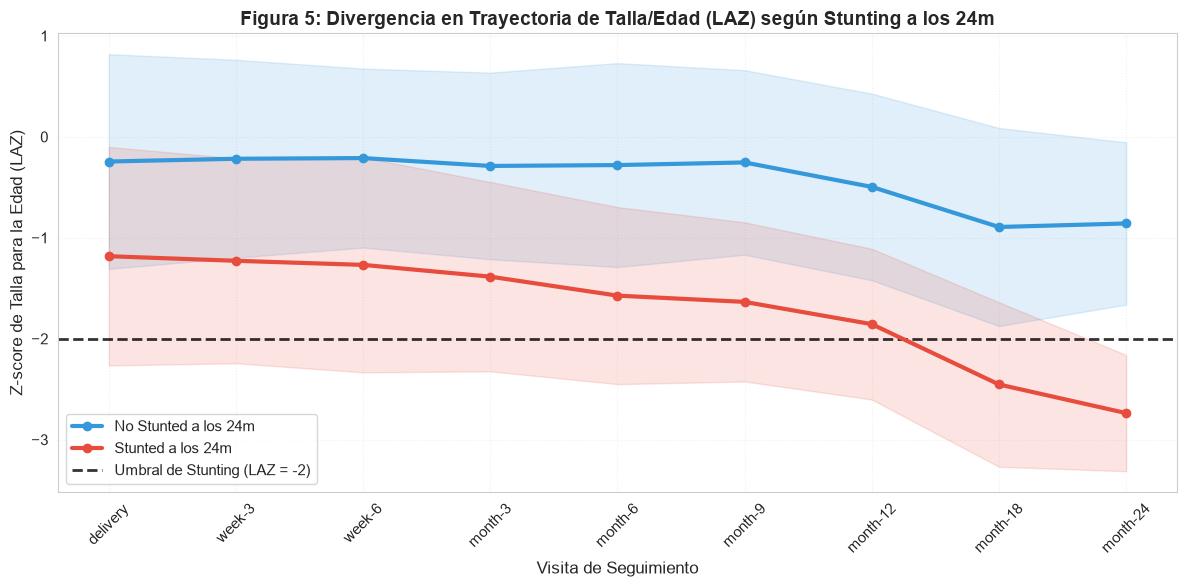

In [20]:
# ============================================================================
# - PASO 7.1.1 (Ajuste para el reporte): Trayectoria de LAZ según stunting a los 24 meses -
# ============================================================================
# Nos enfocamos ÚNICAMENTE en LAZ (zlen) porque es la definición clínica exacta de stunting.
# Esto permite ver con claridad la divergencia de las trayectorias en el reporte.

plt.figure(figsize=(12, 6))

for st_state, color, label in [('no', '#3498db', 'No Stunted a los 24m'), ('yes', '#e74c3c', 'Stunted a los 24m')]:
    subset = df[df['stunted_24'] == st_state]
    
    # Calculamos media y desviación estándar por visita
    means = subset.groupby('visit')['zlen'].mean().reindex(orden_visitas)
    stds = subset.groupby('visit')['zlen'].std().reindex(orden_visitas)
    
    # Línea principal
    plt.plot(means.index, means.values, marker='o', color=color, linewidth=3, label=label, zorder=3)
    # Banda de sombra (± 1 DE) para mostrar dispersión de la cohorte
    plt.fill_between(means.index, means.values - stds.values, means.values + stds.values, color=color, alpha=0.15)

# Umbral clínico de Stunting
plt.axhline(-2, ls='--', color='black', alpha=0.8, linewidth=2, label='Umbral de Stunting (LAZ = -2)')

plt.title('Figura 5: Divergencia en Trayectoria de Talla/Edad (LAZ) según Stunting a los 24m', fontsize=14, fontweight='bold')
plt.ylabel('Z-score de Talla para la Edad (LAZ)', fontsize=12)
plt.xlabel('Visita de Seguimiento', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3, linestyle=':')
plt.legend(fontsize=11, loc='lower left')
plt.tight_layout()
plt.savefig('figures/fig5_laz_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1.1 Trayectoria de LAZ según stunting a los 24 meses (Figura 5, versión reporte)

Al aislar el Z-score de Talla para la Edad (LAZ) —la definición clínica exacta del stunting— la figura gana claridad y confirma cuatro lecturas centrales:

- **Señal presente desde el nacimiento:** el grupo que terminará stunted ya nace ≈1 SD por debajo del grupo sano (LAZ ≈ −1.2 vs ≈ −0.2), evidenciando un componente basal/intrauterino del riesgo.
- **Divergencia progresiva, no súbita:** la brecha se amplía de ≈1 SD al nacimiento a ≈1.8–1.9 SD a los 24 meses. La curva roja declina de forma sostenida (−1.4 a M3, −1.6 a M6, −1.85 a M12) y **cruza el umbral clínico de −2 entre los meses 12 y 18**, cayendo a ≈ −2.7 al final del seguimiento.
- **Faltering generalizado de la cohorte:** incluso el grupo sano declina tras el mes 12 (de ≈ −0.25 a ≈ −0.9 a los 24 m), coherente con el salto de prevalencia del Paso 4.2; el deterioro postnatal afecta a todos, pero es mucho más severo en el grupo de riesgo.
- **Las bandas de ±1 DE se superponen en el periodo temprano:** un LAZ aislado al nacimiento no clasifica perfectamente a los bebés (hay sanos con LAZ bajos y viceversa); la separación se vuelve nítida desde M6–M9. Esto implica que el valor predictivo está en la **trayectoria/pendiente**, no en una medición puntual.

**Implicaciones de modelado:**
1. El modelo debe combinar **features basales** (que capturan el déficit al nacimiento) con **features postnales tempranas** (LAZ y su pendiente nacimiento→M3/M6), que capturan la inercia de la caída antes del cruce del umbral.
2. La ventana de alerta óptima se ubica entre M3 y M9: emitir la predicción antes del cruce de −2 (M12–M18) deja margen real de intervención.
3. LAZ como único indicador simplifica el mensaje clínico del tablero: "pendiente de talla" como bandera de alerta.

> ✍️ **Celda Markdown — Insights del equipo (Paso 7.1.1):** Sugerencia: *"La curva roja 'avisa' desde el nacimiento y se despega de forma sostenida: un sistema que monitoree la pendiente de LAZ en los primeros 3–6 meses podría alertar hasta un año antes de que el bebé cruce el umbral clínico de −2, que es cuando el daño ya es visible en la consulta."*

📌 *Nota para el informe:* esta figura de panel único **reemplaza a la Figura 5 de tres paneles** en el reporte; las bandas de ±1 DE comunican además la variabilidad de la cohorte sin saturar el espacio.

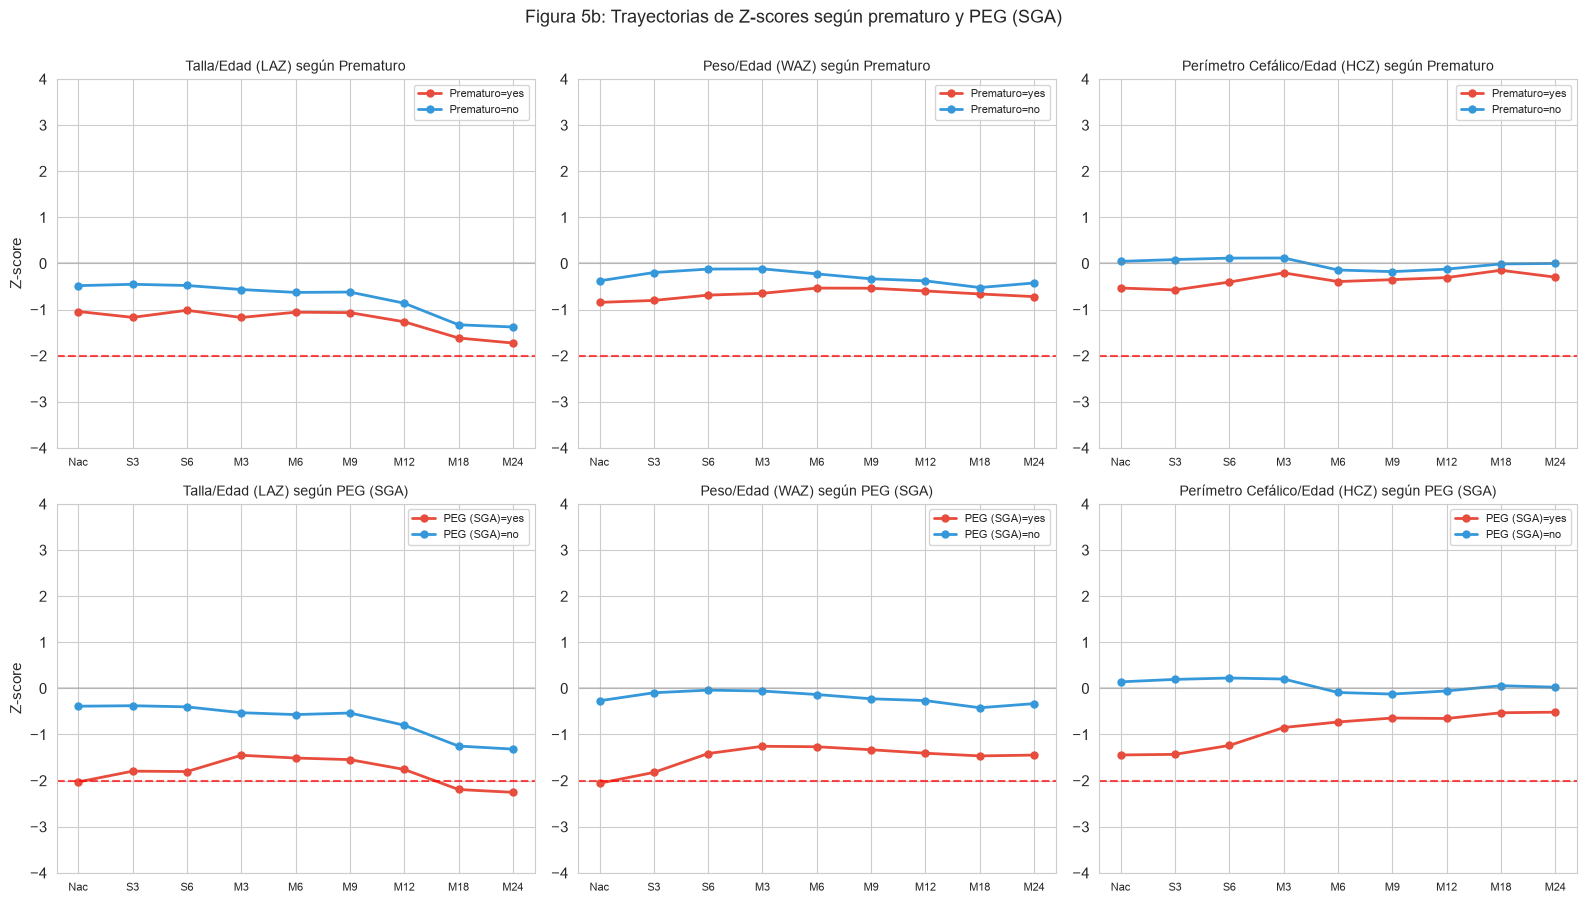

Tamaños de grupo (bebés únicos):
  preterm: {'no': 302, 'yes': 31}
  sga: {'no': 277, 'yes': 29, nan: 27}

Z-scores medios (LAZ / WAZ) al nacimiento y a los 24 meses:
  preterm=yes: n≈31 | LAZ nac=-1.04 → 24m=-1.73 | WAZ nac=-0.84 → 24m=-0.72
  preterm=no: n≈302 | LAZ nac=-0.48 → 24m=-1.38 | WAZ nac=-0.38 → 24m=-0.42
  sga=yes: n≈29 | LAZ nac=-2.03 → 24m=-2.25 | WAZ nac=-2.06 → 24m=-1.45
  sga=no: n≈277 | LAZ nac=-0.39 → 24m=-1.32 | WAZ nac=-0.27 → 24m=-0.33


In [21]:
# --- PASO 7.2: Trayectorias separadas por prematuro y PEG (SGA) ---
# Conecta con el "núcleo canguro": prematuros y PEG son la población
# objetivo del Método Madre Canguro (MMC).

orden_visitas = ['delivery', 'week-3', 'week-6', 'month-3', 'month-6',
                 'month-9', 'month-12', 'month-18', 'month-24']
if 'visit_order' not in df.columns:
    df['visit_order'] = df['visit'].map({v: i for i, v in enumerate(orden_visitas)})

z_scores = ['zlen', 'zwei', 'zhc']
titulos  = ['Talla/Edad (LAZ)', 'Peso/Edad (WAZ)', 'Perímetro Cefálico/Edad (HCZ)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Fila 1: por prematuro | Fila 2: por PEG (SGA)
for j, (col_grupo, nombre) in enumerate([('preterm', 'Prematuro'), ('sga', 'PEG (SGA)')]):
    for i, (z_col, titulo) in enumerate(zip(z_scores, titulos)):
        ax = axes[j, i]
        for grupo, color in [('yes', '#e74c3c'), ('no', '#3498db')]:
            tr = (df[df[col_grupo] == grupo]
                  .groupby('visit_order')[z_col].mean()
                  .reindex(range(len(orden_visitas))))
            ax.plot(tr.index, tr.values, marker='o', color=color,
                    label=f'{nombre}={grupo}', linewidth=2, markersize=5)
        ax.axhline(y=-2, color='red', linestyle='--', alpha=0.7)
        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
        ax.set_title(f'{titulo} según {nombre}', fontsize=10)
        ax.set_xticks(range(len(orden_visitas)))
        ax.set_xticklabels(['Nac','S3','S6','M3','M6','M9','M12','M18','M24'], fontsize=8)
        ax.set_ylim(-4, 4)
        ax.legend(fontsize=8)
        if i == 0:
            ax.set_ylabel('Z-score')

plt.suptitle('Figura 5b: Trayectorias de Z-scores según prematuro y PEG (SGA)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('figures/fig5b_trayectorias_preterm_sga.png', dpi=150, bbox_inches='tight')
plt.show()

# Tamaños de grupo (bebés únicos)
print("Tamaños de grupo (bebés únicos):")
print("  preterm:", df.drop_duplicates('newid')['preterm'].value_counts().to_dict())
print("  sga:", df.drop_duplicates('newid')['sga'].value_counts(dropna=False).to_dict())

# Brecha entre grupos al nacimiento y a los 24 meses (¿hay catch-up o persiste?)
print("\nZ-scores medios (LAZ / WAZ) al nacimiento y a los 24 meses:")
for col_grupo in ['preterm', 'sga']:
    for grupo in ['yes', 'no']:
        sub = df[df[col_grupo] == grupo]
        d   = sub[sub['visit'] == 'delivery']
        m24 = sub[sub['visit'] == 'month-24']
        print(f"  {col_grupo}={grupo}: n≈{d['newid'].nunique()} | "
              f"LAZ nac={d['zlen'].mean():.2f} → 24m={m24['zlen'].mean():.2f} | "
              f"WAZ nac={d['zwei'].mean():.2f} → 24m={m24['zwei'].mean():.2f}")

### 7.2 Trayectorias según prematuro y PEG (SGA): el "núcleo canguro" (Figura 5b)

Tamaños de grupo: 31 prematuros (9.3%), 29 PEG (8.7%) y 27 faltantes de `sga` (se manejarán con indicador). Por los n pequeños, las medias deben leerse con cautela, pero los patrones son coherentes con los pasos previos.

- **Prematurez → déficit inicial moderado con catch-up:** los prematuros nacen con LAZ ≈ −1.0 vs −0.5 de los no prematuros (brecha ≈0.6 SD) y WAZ ≈ −0.8 vs −0.4. En WAZ y HCZ la brecha se **cierra** con el tiempo (catch-up postnatal, típico de un buen manejo nutricional), aunque en LAZ ambos grupos declinan después del mes 12.
- **PEG (SGA) → déficit inicial severo, catch-up parcial y recaída:** los PEG nacen con LAZ/WAZ ≈ −2 (por debajo del umbral, coherente con restricción de crecimiento intrauterino; brecha ≈1.6–1.8 SD, **~3 veces la de la prematurez**). Recuperan durante los primeros meses (WAZ de −2.1 a ≈ −1.3; LAZ hasta ≈ −1.4), pero **el LAZ vuelve a caer bajo −2 desde el mes 18** (−2.25 a los 24 m): catch-up temprano que no se sostiene en talla.
- **El RCIU pesa más que la prematurez:** la brecha inicial de LAZ asociada a PEG triplica a la de prematuro, confirmando que la restricción de crecimiento intrauterino es la vía dominante de vulnerabilidad (coherente con el Paso 6.2).

**Interpretación en contexto del proyecto (Canguro):**
- Los prematuros y PEG —población objetivo del Método Madre Canguro— llegan con déficit de crecimiento al nacer, pero con dinámicas distintas: el prematuro tiende a recuperar peso y perímetro cefálico, mientras que el PEG recupera parcialmente y luego se deteriora de nuevo en talla durante el periodo de alimentación complementaria.
- La recaída de los PEG bajo −2 después del mes 12 muestra que **el catch-up es modificable pero frágil**: el seguimiento y el soporte nutricional deben sostenerse más allá del primer año (coherente con el salto de prevalencia del Paso 4.2).

**Implicaciones de modelado:**
1. `preterm` y `sga` son features basales relevantes; `sga` debería ser un predictor fuerte de la trayectoria de LAZ/stunting.
2. El riesgo basal **no es determinista**: el catch-up parcial observado justifica incluir **features postnales tempranas** (Z-scores y pendientes a los 3–6 meses) para capturar la respuesta al seguimiento.
3. Muestras pequeñas (31/29) y 27 faltantes de `sga` → usar indicador de missing, particionar por bebé y no sobre-interpretar medias de subgrupo.

Bebés con target 12m: 326 | con target 24m: 323

--- hfia_enr ---
            n  st12_pct  st24_pct
hfia_enr                         
mild       39       8.1      29.7
moderate  110      12.1      23.6
secured    97      18.9      29.8
severe     84      15.5      34.9

--- depression ---
                      n  st12_pct  st24_pct
depression                                 
mild                 87       9.4      27.4
moderate or severe   11       0.0      27.3
no depression       235      17.8      30.3

--- enrol_anemia ---
                n  st12_pct  st24_pct
enrol_anemia                         
no            210      17.9      30.2
yes           101      11.2      29.9

--- enrol_hiv_status_cat ---
                        n  st12_pct  st24_pct
enrol_hiv_status_cat                         
Negative              162      15.0      27.2
Positive              171      15.1      31.5

--- educ_cat_n ---
                       n  st12_pct  st24_pct
educ_cat_n                           

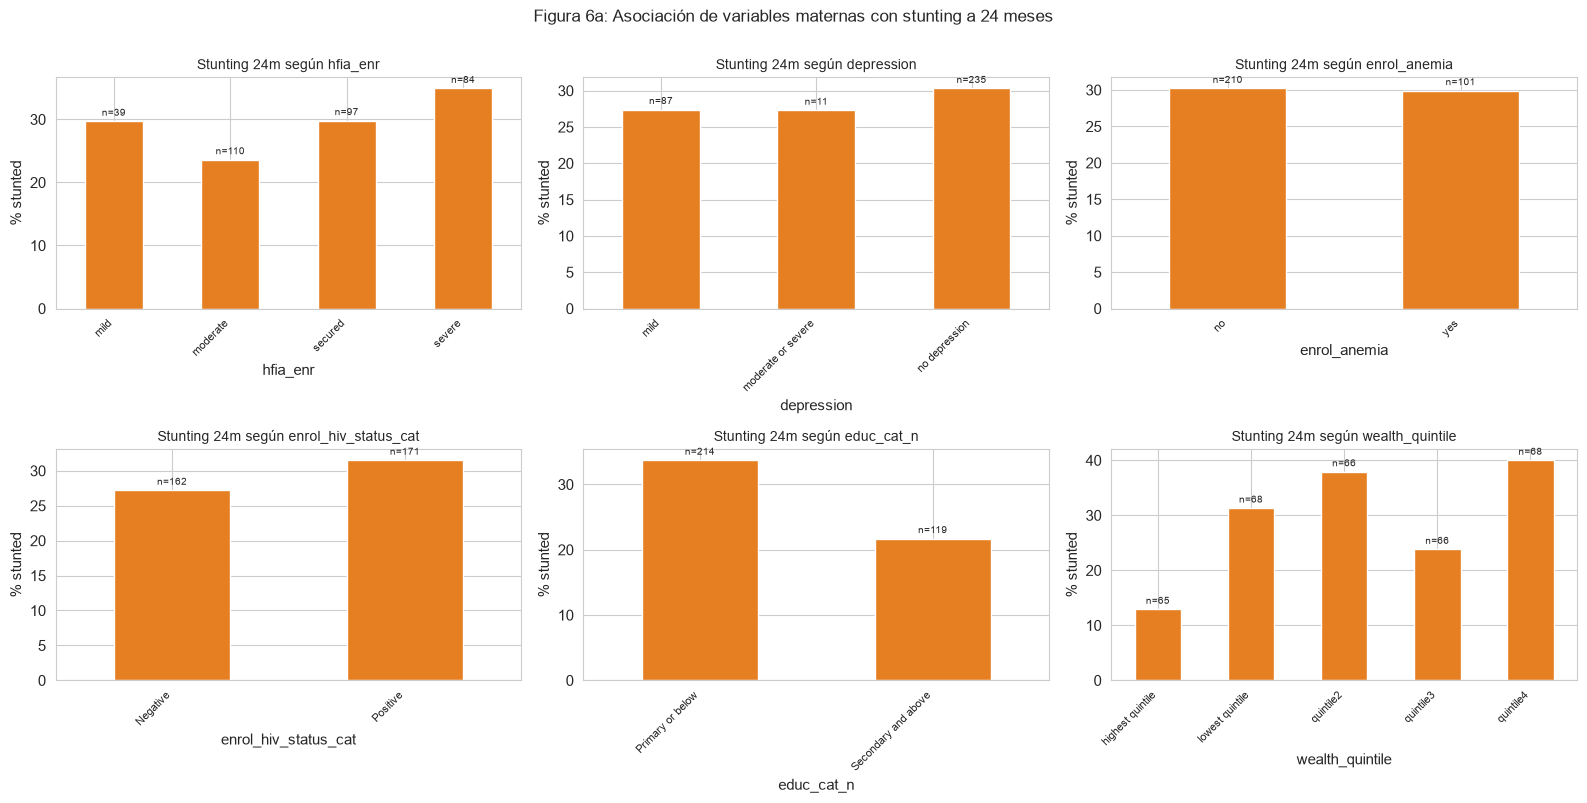

In [22]:
# --- PASO 8: Análisis de asociación - Features maternas vs Stunting ---
# --- PASO 8.1: Asociación de variables maternas con stunting (nivel bebé) ---
# Targets a nivel de bebé en dos horizontes: 12 y 24 meses
for hor, vis in [('stunted_12', 'month-12'), ('stunted_24', 'month-24')]:
    if hor not in df.columns:
        tmp = (df.loc[df['visit'] == vis]
                 .drop_duplicates('newid')[['newid', 'stunted']]
                 .rename(columns={'stunted': hor}))
        df = df.merge(tmp, on='newid', how='left')

bebes = df.drop_duplicates('newid').copy()
print(f"Bebés con target 12m: {bebes['stunted_12'].notna().sum()} | "
      f"con target 24m: {bebes['stunted_24'].notna().sum()}")

def pct_yes(s):
    d = s.notna().sum()
    return round(100 * (s == 'yes').sum() / d, 1) if d else np.nan

def assoc(col):
    return bebes.groupby(col).agg(
        n=('newid', 'size'),
        st12_pct=('stunted_12', pct_yes),
        st24_pct=('stunted_24', pct_yes))

maternas = ['hfia_enr', 'depression', 'enrol_anemia', 'enrol_hiv_status_cat',
            'educ_cat_n', 'wealth_quintile', 'momage_cat', 'mom_muac_cat',
            'parity', 'marital_cat']

for col in maternas:
    print(f"\n--- {col} ---")
    print(assoc(col))

# Figura 6a: % stunting a 24m para las 6 variables maternas clave
fig6_vars = ['hfia_enr', 'depression', 'enrol_anemia',
             'enrol_hiv_status_cat', 'educ_cat_n', 'wealth_quintile']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, fig6_vars):
    g = bebes.groupby(col)['stunted_24'].apply(pct_yes)
    g.plot(kind='bar', ax=ax, color='#e67e22')
    ax.set_title(f'Stunting 24m según {col}', fontsize=10)
    ax.set_ylabel('% stunted')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    for i, cat in enumerate(g.index):
        ax.annotate(f"n={(bebes[col]==cat).sum()}", (i, g.loc[cat]),
                    textcoords="offset points", xytext=(0, 4), ha='center', fontsize=7)
plt.suptitle('Figura 6a: Asociación de variables maternas con stunting a 24 meses',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('figures/fig6a_asoc_maternas.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 Asociación de variables maternas con stunting a 12 y 24 meses (Figura 6a)

Se calculó la prevalencia de stunting por categoría de cada variable materna en dos horizontes (12 y 24 meses; n=326 y n=323 bebés con target disponible). El análisis revela tres niveles de señal:

**Señales consistentes y con gradiente socioeconómico/nutricional:**
- **Educación materna:** la asociación más limpia y consistente en ambos horizontes: *Primary or below* 33.7% vs *Secondary and above* 21.7% a 24m (+12.0 pp), y 17.7% vs 10.3% a 12m (+7.4 pp). El gradiente se **amplía con el tiempo**, coherente con un efecto acumulativo del contexto socioeconómico.
- **Quintil de riqueza:** el quintil más alto actúa como factor protector claro (12.9% a 24m) frente al resto (23.8–40.0%). El patrón no es monótono (quintile4 alcanza 40.0%), lo que sugiere ruido por tamaños de grupo pequeños (n≈66) más que ausencia de efecto.
- **MUAC materno:** la desnutrición materna al enrolamiento muestra el efecto más fuerte (66.7% de stunting a 24m vs ~20–30% en los demás grupos; también 33.3% a 12m), biológicamente plausible. **Cautela:** n=9, por lo que el estimado es inestable y debe leerse como hipótesis.
- **Estado HIV:** diferencia modesta a 24m (Positive 31.5% vs Negative 27.2%) e inexistente a 12m: la exposición al VIH aporta riesgo leve y tardío, no temprano.

**Señales débiles o nulas:** depresión materna (27.3–30.3%, sin gradiente), anemia al enrolamiento (29.9% vs 30.2%), paridad (29.2% vs 29.7%), edad materna (24.0–31.6% sin patrón) y estado marital (28.8% vs 32.7%) no discriminan stunting en esta cohorte.

**Inseguridad alimentaria (HFIA):** *severe* presenta la mayor prevalencia a 24m (34.9%), pero el gradiente no es monótono (*moderate* 23.6% por debajo de *secured* 29.8%), lo que indica una señal real pero ruidosa.

**Lectura en contexto del proyecto:**
- Los determinantes que discriminan son **socioeconómicos y nutricionales** (educación, riqueza, estado nutricional materno), no clínicos ni psicosociales. Son, además, variables *monitoreables/intervenibles* desde programas tipo Madre Canguro (soporte nutricional y social).
- Las asociaciones se **fortalecen a 24m**, coherente con la naturaleza acumulativa del stunting observada en los Pasos 4 y 7.
- Tomadas solas, las variables basales muestran poder discriminatorio **modesto**: esto refuerza la decisión de complementarlas con **features postnales tempranas** (Z-scores y pendientes de los primeros meses), que en los Pasos 7.1–7.2 mostraron divergencia temprana clara.

**Implicaciones de modelado:**
1. Priorizar como features basales: `educ_cat_n`, `wealth_quintile`, `mom_muac_cat` y `enrol_hiv_status_cat`; las demás aportan poco de forma univariada (aunque pueden conservar valor en combinación multivariada).
2. Categorías con n muy pequeño (`mom_muac_cat=undernutrition` n=9; `depression=moderate or severe` n=11) → agrupar o regularizar para evitar sobreajuste a estimados inestables.
3. El ranking univariado de este paso alimentará el Paso 8.3 (selección de features) y se validará con el modelo multivariado.


--- preterm ---
           n  st12_pct  st24_pct
preterm                         
no       302      13.9      28.8
yes       31      25.8      35.5

--- sga ---
       n  st12_pct  st24_pct
sga                         
no   277      13.9      27.4
yes   29      25.0      57.1

--- lbw ---
       n  st12_pct  st24_pct
lbw                         
no   311      13.1      28.4
yes   20      36.8      50.0

--- b1_sex ---
          n  st12_pct  st24_pct
b1_sex                         
female  156       8.5      26.1
male    177      20.8      32.4

--- caesarean ---
             n  st12_pct  st24_pct
caesarean                         
no         278      15.0      30.6
yes         49      15.2      19.6


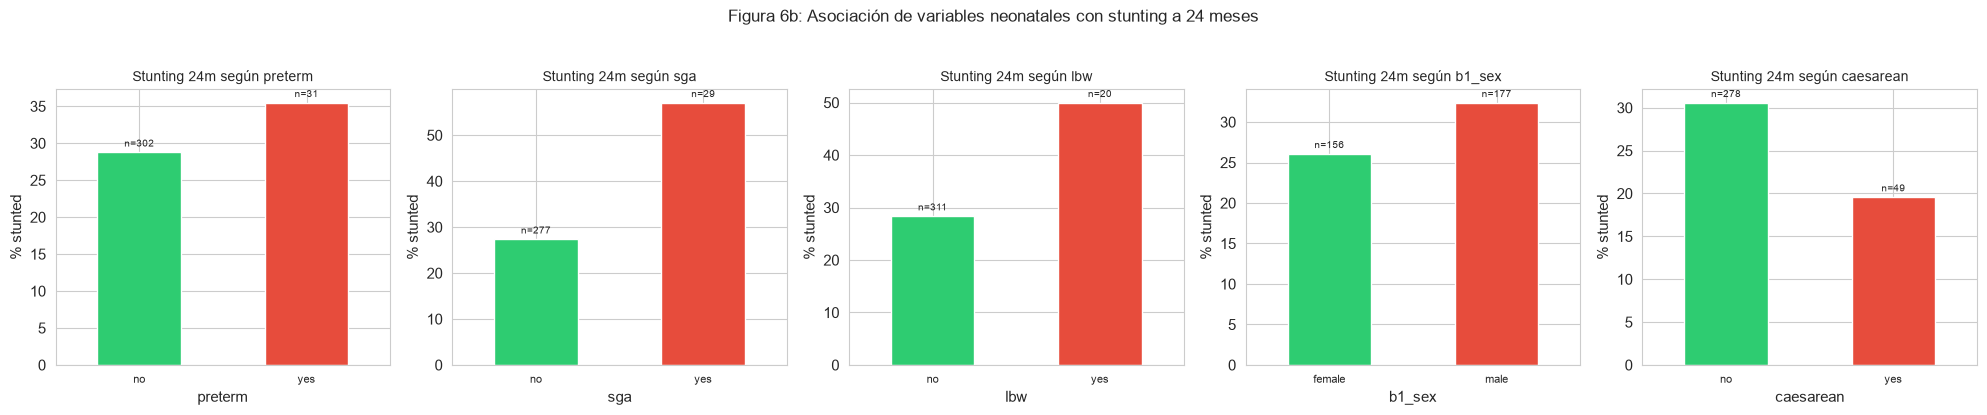

In [23]:
# --- PASO 8.2: Asociación de variables neonatales con stunting ---
neonatales = ['preterm', 'sga', 'lbw', 'b1_sex', 'caesarean']

for col in neonatales:
    print(f"\n--- {col} ---")
    print(assoc(col))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, neonatales):
    g = bebes.groupby(col)['stunted_24'].apply(pct_yes)
    g.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'][:len(g)])
    ax.set_title(f'Stunting 24m según {col}', fontsize=10)
    ax.set_ylabel('% stunted')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)
    for i, cat in enumerate(g.index):
        ax.annotate(f"n={(bebes[col]==cat).sum()}", (i, g.loc[cat]),
                    textcoords="offset points", xytext=(0, 4), ha='center', fontsize=7)
plt.suptitle('Figura 6b: Asociación de variables neonatales con stunting a 24 meses',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('figures/fig6b_asoc_neonatales.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Asociación de variables neonatales con stunting a 12 y 24 meses (Figura 6b)

Las condiciones al nacimiento muestran, en conjunto, **señales más fuertes y consistentes** que la mayoría de las variables maternas del Paso 8.1:

- **SGA (pequeño para edad gestacional) — el predictor neonatal más fuerte:** 57.1% de stunting a 24m vs 27.4% en no-PEG (+29.7 pp), más del doble de riesgo. Coherente con las trayectorias del Paso 7.2, donde los PEG arrancan con LAZ ≈ −2. Ya a los 12m la brecha es amplia (25.0% vs 13.9%).
- **Bajo peso al nacer (BPN):** 50.0% vs 28.4% a 24m (+21.6 pp) y 36.8% vs 13.1% a 12m (+23.7 pp). Señal fuerte y temprana.
- **Prematurez:** 35.5% vs 28.8% a 24m (+6.7 pp), pero con una brecha mayor a 12m (25.8% vs 13.9%, +11.9 pp). El estrechamiento de la brecha con el tiempo sugiere **catch-up relativo** de los prematuros mientras el grupo a término se deteriora tras el mes 12 — coherente con el Paso 7.2.
- **Sexo del bebé:** los masculinos presentan más stunting en ambos horizontes (32.4% vs 26.1% a 24m; 20.8% vs 8.5% a 12m), en línea con la mayor vulnerabilidad biológica masculina reportada en la literatura.
- **Cesárea — asociación inversa:** 19.6% vs 30.6% a 24m. **Cautela:** no debe leerse como efecto protector causal; probablemente es un marcador de acceso a servicios de salud/nivel socioeconómico. Útil como predictor, pero su interpretación debe ser cuidadosa.

**Lectura en contexto del proyecto:**
- `sga`, `lbw` y `preterm` definen exactamente a la población vulnerable que atiende el Método Madre Canguro; su fuerte asociación con stunting justifica **priorizar a estos bebés en el seguimiento intensivo** y los confirma como features basales clave del modelo.
- Comparado con el Paso 8.1, las variables neonatales (SGA +29.7 pp, BPN +21.6 pp) discriminan más que la mayoría de las maternas (educación +12.0 pp, HIV +4.3 pp), con la excepción de MUAC e inseguridad alimentaria severa. El Paso 8.3 formalizará este ranking.
- **Limitación:** los subgrupos expuestos son pequeños (SGA n=29, BPN n=20, prematuros n=31), por lo que los porcentajes (p. ej. 57.1%) son estimados inestables; se leerán como tendencias y se manejarán con modelos robustos.

**Implicaciones de modelado:**
1. Incluir `sga`, `lbw`, `preterm` y `b1_sex` como features basales (conocidas al parto, sin riesgo de fuga temporal).
2. `caesarean`: evaluar su inclusión; aporta señal pero su asociación inversa está probablemente confundida — no interpretar como causal.
3. La combinación de features neonatales fuertes + Z-scores postnales tempranos (Paso 7) constituye el set predictor más prometedor para la alerta temprana.

Ranking univariado (brecha en pp de stunting a 24m):
            variable  gap_pp cat_mayor_riesgo    cat_menor_riesgo
                 sga    29.7              yes                  no
     wealth_quintile    27.1        quintile4    highest quintile
                 lbw    21.6              yes                  no
          educ_cat_n    12.0 Primary or below Secondary and above
            hfia_enr    11.3           severe            moderate
           caesarean    11.0               no                 yes
        mom_muac_cat    10.3           normal        above normal
          momage_cat     7.6         26 to 35         35 and more
             preterm     6.7              yes                  no
              b1_sex     6.3             male              female
enrol_hiv_status_cat     4.3         Positive            Negative
         marital_cat     3.9            Other             Married
          depression     2.9    no depression                mild
              parity   

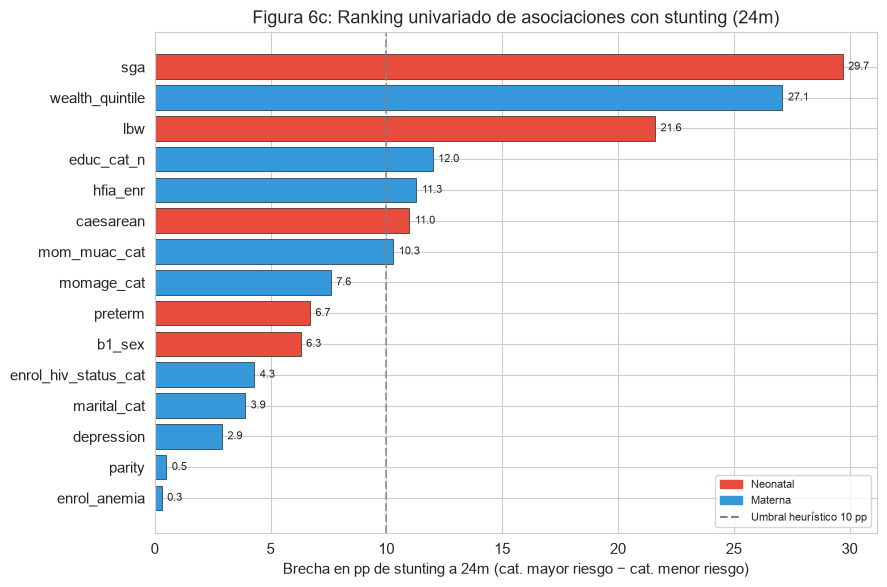

In [25]:
# --- PASO 8.3 (completo): Ranking univariado + Figura 6c ---
# (Re)calcula rank_df y luego grafica. Requiere 8.1 y 8.2 corridos.

ranking = []
for col in maternas + neonatales:
    g = bebes.groupby(col).agg(n=('newid', 'size'), p=('stunted_24', pct_yes))
    g = g[g.n >= 15]                      # solo categorías con n>=15
    if len(g) >= 2:
        ranking.append({'variable': col, 'gap_pp': round(g.p.max() - g.p.min(), 1),
                        'cat_mayor_riesgo': g.p.idxmax(),
                        'cat_menor_riesgo': g.p.idxmin()})
rank_df = pd.DataFrame(ranking).sort_values('gap_pp', ascending=False)
print("Ranking univariado (brecha en pp de stunting a 24m):")
print(rank_df.to_string(index=False))

# --- Figura 6c ---
from matplotlib.patches import Patch

rd = rank_df.sort_values('gap_pp', ascending=True)   # mayor brecha queda arriba
tipo = ['Neonatal' if v in neonatales else 'Materna' for v in rd['variable']]
colores = ['#e74c3c' if t == 'Neonatal' else '#3498db' for t in tipo]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(rd['variable'], rd['gap_pp'], color=colores, edgecolor='black', linewidth=0.4)
for y, g in enumerate(rd['gap_pp']):
    ax.annotate(f"{g:.1f}", (g, y), textcoords="offset points",
                xytext=(4, 0), va='center', fontsize=8)
ax.axvline(10, ls='--', color='gray', alpha=0.7)
ax.set_xlabel('Brecha en pp de stunting a 24m (cat. mayor riesgo − cat. menor riesgo)')
ax.set_title('Figura 6c: Ranking univariado de asociaciones con stunting (24m)')
ax.legend(handles=[Patch(color='#e74c3c', label='Neonatal'),
                   Patch(color='#3498db', label='Materna'),
                   plt.Line2D([], [], ls='--', color='gray', label='Umbral heurístico 10 pp')],
          loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('figures/fig6c_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Ranking univariado de asociaciones con stunting a 24 meses (Figura 6c)

La Figura 6c ordena cada variable por la brecha (en puntos porcentuales, pp) entre la prevalencia de stunting de su categoría de mayor y menor riesgo (solo categorías con n≥15), con un umbral heurístico de 10 pp y color por dominio (rojo = neonatal, azul = materno). Se distinguen tres niveles de asociación:

- **Nivel fuerte (>20 pp):** `sga` (29.7), `wealth_quintile` (27.1), `lbw` (21.6). Las condiciones de crecimiento intrauterino y la riqueza del hogar son los mejores predictores univariados de stunting a los 24 meses.
- **Nivel moderado (10–12 pp):** `educ_cat_n` (12.0), `hfia_enr` (11.3), `caesarean` (11.0), `mom_muac_cat` (10.3).
- **Nivel débil (<8 pp):** edad materna (7.6), `preterm` (6.7), sexo del bebé (6.3), HIV materno (4.3), estado marital (3.9), depresión (2.9); `parity` (0.5) y `enrol_anemia` (0.3) son prácticamente nulas.

**Lecturas clave:**
- **SGA y LBW dominan sobre la prematurez:** `preterm` (6.7 pp) queda muy por debajo de `sga` y `lbw` → lo que más importa es la *restricción de crecimiento intrauterino*, no la prematuridad per se (coherente con los Pasos 7.2 y 8.2).
- **Riqueza no monótona:** el mayor riesgo está en `quintile4` (40.0%) y el menor en el quintil más alto (12.9%); el factor protector es estar en la cima, no un gradiente lineal → codificar como categórica, no ordinal.
- **Cesárea con asociación inversa** (mayor riesgo en parto vaginal: 30.6% vs 19.6%): probablemente proxy de acceso a servicios/SES; útil como predictor, pero sin interpretación causal.
- **Efecto del filtro n≥15:** la desnutrición materna (66.7% stunted, n=9) no entra al ranking; la brecha de 10.3 pp de `mom_muac_cat` compara normal vs above normal. La señal de desnutrición, aunque de muestra pequeña, es fuerte y deberá rescatarse con un flag binario en el modelado.
- **HIV materno débil (4.3 pp):** la exposición por sí sola no discrimina fuertemente el stunting; dominan los factores socioeconómicos y de crecimiento.

**Implicaciones de modelado (selección de features):**
1. Prioridad univariada: `sga`, `lbw`, `wealth_quintile`, `educ_cat_n`, `hfia_enr`, `caesarean`, `mom_muac_cat` — las 7 variables sobre el umbral de 10 pp combinan ambos dominios (3 neonatales, 4 maternas), lo que justifica un modelo que integre crecimiento intrauterino + determinantes sociales.
2. El umbral de 10 pp es un *screening* heurístico, no una regla definitiva: variables débiles (p. ej. `preterm`, `b1_sex`) pueden aportar valor en combinación y se evaluarán en el modelo multivariado.
3. Este ranking es descriptivo; la selección final se validará con el modelo multivariado y SHAP (semanas 4–5).

In [26]:
# --- PASO 9: Preparación para el modelado - Definición Features/Target ---
# --- PASO 9.1: Contrato de modelado (especificación, sin código de preprocesamiento) ---
features_enrolamiento = ['enrol_hiv_status_cat', 'momage_cat', 'educ_cat_n', 'marital_cat',
                         'hfia_enr', 'wealth_quintile', 'depression', 'mom_muac_cat',
                         'parity', 'enrol_anemia']
features_nacimiento = ['b1_sex', 'gestage_final', 'caesarean', 'preterm', 'sga', 'lbw']

print("=" * 64)
print("CONTRATO DE MODELADO (especificación para semanas 4-5)")
print("=" * 64)
print(f"\nFeatures al enrolamiento ({len(features_enrolamiento)}): conocidas antes del parto.")
print(f"Features al nacimiento ({len(features_nacimiento)}): conocidas al parto.")
print("\nFeatures postnales tempranas (a INGENIAR en semanas 4-5, respetando temporalidad):")
print("  - Z-scores en week-3 / month-3 (zlen, zwei, zhc)")
print("  - Pendientes de trayectoria (p.ej. dLAZ nac->M3)")
print("  - 'zac' EXCLUIDO de features tempranas (no se mide antes del mes 6, Paso 3)")
print("\nTargets (horizontes explícitos):")
print("  - Primario: stunted_24 (desnutrición crónica consolidada)")
print("  - Secundario: stunted_12")
print("\nReglas anti-leakage:")
print("  - Ninguna medición posterior al horizonte de predicción entra como feature.")
print("  - Partición AGRUPADA por bebé (newid): sin bebés repetidos entre folds.")
print("  - Imputación/balanceo SOLO dentro del fold de entrenamiento.")
print("\nEvaluación (target desbalanceado): F1, PR-AUC, ROC-AUC, sensibilidad;")
print("  class_weight='balanced' como baseline de manejo de desbalance.")

CONTRATO DE MODELADO (especificación para semanas 4-5)

Features al enrolamiento (10): conocidas antes del parto.
Features al nacimiento (6): conocidas al parto.

Features postnales tempranas (a INGENIAR en semanas 4-5, respetando temporalidad):
  - Z-scores en week-3 / month-3 (zlen, zwei, zhc)
  - Pendientes de trayectoria (p.ej. dLAZ nac->M3)
  - 'zac' EXCLUIDO de features tempranas (no se mide antes del mes 6, Paso 3)

Targets (horizontes explícitos):
  - Primario: stunted_24 (desnutrición crónica consolidada)
  - Secundario: stunted_12

Reglas anti-leakage:
  - Ninguna medición posterior al horizonte de predicción entra como feature.
  - Partición AGRUPADA por bebé (newid): sin bebés repetidos entre folds.
  - Imputación/balanceo SOLO dentro del fold de entrenamiento.

Evaluación (target desbalanceado): F1, PR-AUC, ROC-AUC, sensibilidad;
  class_weight='balanced' como baseline de manejo de desbalance.


### 9.1 Contrato de modelado (especificación para semanas 4–5)

Esta sección cierra el EDA y funciona como *contrato* entre la fase exploratoria y la de modelado: aquí no se entrena ningún modelo, pero queda definida y **justificada con hallazgos del EDA** cada decisión posterior (Recomendación 1 del enunciado).

**Inventario de features (16 basales + postnales tempranas):**
- *10 maternas al enrolamiento* (conocidas antes del parto): contexto sociodemográfico y clínico (educación, riqueza, inseguridad alimentaria, HIV, depresión, anemia, MUAC, edad, paridad, estado marital).
- *6 al nacimiento* (conocidas al parto): sexo, edad gestacional, cesárea, prematurez, PEG (SGA) y bajo peso al nacer. Con estas 16 features el modelo puede emitir una alerta **en tiempo cero** (al egreso/enrolamiento), el escenario de mayor valor operativo para un programa de seguimiento.
- *Features postnales tempranas (a ingeniar en semanas 4–5)*: Z-scores en week-3/month-3 (zlen, zwei, zhc) y pendientes de trayectoria (p. ej., dLAZ nacimiento→M3). Capturan la "firma longitudinal" que el EDA mostró como lo más discriminante (Paso 7) y definen un segundo modelo más potente para visitas de seguimiento.
- *Exclusión explícita de `zac` como feature temprana*: el EDA (Paso 3) mostró que no se mide antes del mes 6; usarla implicaría leakage y, en la práctica, una variable no disponible al momento de la alerta temprana.

**Targets con horizonte explícito:**
- Primario: `stunted_24` — desnutrición crónica consolidada a los 24 meses (29.4% a nivel bebé), el desenlace clínicamente más relevante y con mayor señal en el EDA.
- Secundario: `stunted_12` — horizonte intermedio (15%), útil para validar capacidad de detección temprana.

**Reglas anti-leakage (justificadas por el diseño longitudinal):**
1. Ninguna medición posterior al horizonte de predicción entra como feature (temporalidad).
2. **Partición agrupada por bebé (`newid`)**: las visitas de un mismo bebé están correlacionadas; una partición aleatoria filtraría información y inflaría las métricas.
3. Imputación y balanceo **solo dentro del fold de entrenamiento**: calcular imputaciones o sobremuestrear con datos completos filtraría información de validación/prueba.

**Evaluación acorde al desbalance:**
- Se descarta el accuracy como métrica principal (un modelo trivial "todo no" alcanzaría ~71–85% según el horizonte).
- Métricas principales: F1, PR-AUC, ROC-AUC y sensibilidad (priorizando no dejar pasar bebés que terminarán stunted).
- `class_weight='balanced'` como baseline de manejo del desbalance.

Este contrato es el insumo de las semanas 4–5: todo experimento en MLflow deberá declarar qué bloque de features (basales vs. basales+postnales), qué horizonte y qué partición utiliza.

In [28]:
# - PASO 9.2: Dataset plano (una fila por bebé), crudo, sin imputar -
from pathlib import Path

# Detecta la raíz del repo (la carpeta que contiene .git / README.md)
def find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / '.git').exists() or (p / 'README.md').exists():
            return p
    return start

ROOT = find_root()
OUT_DIR = ROOT / 'data' / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)   # usa/crea data/processed en la raíz

cols_model = (['newid'] + features_enrolamiento + features_nacimiento
              + ['stunted_12', 'stunted_24'])
df_model = bebes[cols_model].copy()

print(f"Shape del dataset de modelado: {df_model.shape}")

miss = df_model[features_enrolamiento + features_nacimiento].isna().sum()
print("Missing por feature (se manejará en el pipeline, no aquí):")
print(miss[miss > 0])

print("Balance de targets (nivel bebé):")
print("stunted_12:", df_model['stunted_12'].value_counts(normalize=True).round(3).to_dict())
print("stunted_24:", df_model['stunted_24'].value_counts(normalize=True).round(3).to_dict())

out_path = OUT_DIR / 'model_dataset.csv'
df_model.to_csv(out_path, index=False)
print("Guardado (crudo, sin imputar) en:", out_path)   # <- ruta absoluta para verificar

n = len(df_model)
tr, va = int(n * 0.7), int(n * 0.15)
print(f"Split agrupado por bebé (aprox 70/15/15): train≈{tr}, val≈{va}, test≈{n-tr-va}")

Shape del dataset de modelado: (333, 19)
Missing por feature (se manejará en el pipeline, no aquí):
hfia_enr         3
parity           2
enrol_anemia    22
caesarean        6
sga             27
lbw              2
dtype: int64
Balance de targets (nivel bebé):
stunted_12: {'no': 0.85, 'yes': 0.15}
stunted_24: {'no': 0.706, 'yes': 0.294}
Guardado (crudo, sin imputar) en: c:\Users\CORE I5 7TH\Documents\Learning\MAIA\IV. Semester\4_1_Bimester\Desarrolo de Soluciones\Grupo_23_Microproyecto\yei_microproyecto-pds-grupo23\data\processed\model_dataset.csv
Split agrupado por bebé (aprox 70/15/15): train≈233, val≈49, test≈51


### 9.2 Dataset de modelado (una fila por bebé)

**Estructura:** el dataset plano queda con **333 filas × 19 columnas** (1 ID + 16 features basales + 2 targets), coherente con el contrato del Paso 9.1. La unidad de análisis es el bebé: cada uno aporta un único registro con su información basal y su desenlace final, lo que evita pseudorreplicación por visitas repetidas y hace válida la partición agrupada declarada.

**Missing (se manejará en el pipeline, no aquí):**
- Seis features presentan faltantes: `sga` (27, ~8%), `enrol_anemia` (22, ~7%), `caesarean` (6), `hfia_enr` (3), `parity` (2) y `lbw` (2).
- El dataset se guarda **crudo, sin imputar** (`data/processed/model_dataset.csv`): la imputación es parte del pipeline y se ajustará únicamente con el fold de entrenamiento (regla anti-leakage 3).
- Atención especial a `sga`: fue uno de los predictores más fuertes en el EDA (Paso 8) y es el de mayor missing; se evaluará un *indicador de faltante* para no perder bebés y capturar un posible patrón de missing no aleatorio.

**Balance de targets (nivel bebé):**
- `stunted_24`: 29.4% yes / 70.6% no.
- `stunted_12`: 15% yes / 85% no.
- El horizonte primario es menos desbalanceado que el secundario; ambos son manejables con las métricas declaradas y `class_weight='balanced'`. La diferencia entre horizontes (15% → 29%) es coherente con el hallazgo del EDA de que el stunting *se acumula* durante el seguimiento (Pasos 4 y 8).

**Partición agrupada (≈70/15/15):** train ≈ 233, val ≈ 49, test ≈ 51 bebés.
- Advertencia de tamaño: con ~29% de prevalencia, el conjunto de prueba contendría **apenas ~15 casos positivos de stunted_24** (~8 para stunted_12). Por tanto, las métricas de prueba tendrán varianza alta: se reportarán con intervalos de confianza o corridas repetidas, y ninguna conclusión se basará en una sola corrida.
- Para estabilizar la selección de modelos e hiperparámetros en semanas 4–5 se considerará validación cruzada agrupada y estratificada.

**Reproducibilidad:** el CSV plano queda versionado (DVC) y constituye la única entrada del pipeline de entrenamiento: cualquier experimento de las semanas 4–5 deberá ser reproducible a partir de este archivo más el código del pipeline.